In [1]:
import pandas as pd
import numpy as np




In [2]:
# Extracted ICU stay data (ICUSTAYS).
# Extracted admissions data (ADMISSIONS).
# Extracted demographics (PATIENTS).
# Extracted vitals for the first 24 hours from CHARTEVENTS (SBP, DBP, MBP, HR, Resp, Temp, SpO₂, Height, Weight).
# Calculated BMI.
# Merged all tables into one clean dataset (one row per ICU stay).

# 1. LOAD ICUSTAYS
icu = pd.read_csv(
    "ICUSTAYS.csv",
    usecols=["subject_id","hadm_id","icustay_id","intime","outtime","los","first_careunit"]
)

icu.columns = icu.columns.str.lower()
print(icu.columns)
icu["intime"] = pd.to_datetime(icu["intime"], errors="coerce")
icu["outtime"] = pd.to_datetime(icu["outtime"], errors="coerce")

icu = icu.dropna(subset=["outtime","los"])
print("ICU shape:", icu.shape)


# 2. LOAD ADMISSIONS
adm = pd.read_csv(
    "ADMISSIONS.csv",
    usecols=[
        "subject_id","hadm_id","admittime",
        "admission_type","admission_location","discharge_location",
        "insurance","religion","marital_status","ethnicity"
    ]
)
adm.columns = adm.columns.str.lower()

adm["admittime"] = pd.to_datetime(adm["admittime"], errors="coerce")



# 3. GROUP ETHNICITY 
#    - Start from raw hospital ethnicity text (ADMISSIONS.ethnicity)
#    - Map many fine-grained labels to a small set of high-level groups:
#      WHITE, BLACK, ASIAN, HISPANIC/LATINO, OTHER, UNKNOWN/NOT DISCLOSED

def group_ethnicity(raw):
    if pd.isna(raw):
        return "UNKNOWN/NOT DISCLOSED"

    r = str(raw).upper().strip()

    # 1) UNKNOWN bucket (no information / refused / not recorded)
    unknown_terms = ["UNKNOWN", "UNABLE", "DECLINED", "NOT SPECIFIED", "UNOBTAINABLE"]
    if any(t in r for t in unknown_terms):
        return "UNKNOWN/NOT DISCLOSED"

    # 2) WHITE
    white_terms = ["WHITE", "PORTUGUESE", "IRISH", "EUROPEAN"]
    if any(t in r for t in white_terms):
        return "WHITE"

    # 3) BLACK / AFRICAN
    black_terms = ["BLACK", "AFRICAN"]
    if any(t in r for t in black_terms):
        return "BLACK"

    # 4) ASIAN
    asian_terms = ["ASIAN", "CHINESE", "JAPANESE", "KOREAN", "VIETNAMESE", "FILIPINO", "INDIAN"]
    if any(t in r for t in asian_terms):
        return "ASIAN"

    # 5) HISPANIC / LATINO
    latino_terms = ["HISPANIC", "LATINO", "LATINA", "MEXICAN", "PUERTO RICAN", "CUBAN"]
    if any(t in r for t in latino_terms):
        return "HISPANIC/LATINO"

    # 6) SMALL / MINORITY GROUPS -> OTHER
    #    Multi race, Middle Eastern, Pacific Islander, South American, Caribbean Island, Native American → OTHER
    other_terms = [
        "MULTI RACE", "MULTIRACIAL", "MIDDLE EASTERN",
        "PACIFIC ISLAND", "SOUTH AMERICAN", "CARIBBEAN",
        "NATIVE AMERICAN", "AMERICAN INDIAN", "ALASKA"
    ]
    if any(t in r for t in other_terms):
        return "OTHER"

    # 7) Anything else that doesn't match becomes OTHER
    return "OTHER"

adm["ethnicity_grouped"] = adm["ethnicity"].apply(group_ethnicity)



# 4. AGGREGATE ADMISSIONS BY SUBJECT
#  only wants 1 row per patient)
adm_agg = (
    adm.sort_values("admittime")
       .groupby("subject_id", as_index=False)
       .first()
)

print("Aggregated admissions:", adm_agg.shape)



# 5. LOAD PATIENTS
pat = pd.read_csv(
    "PATIENTS.csv",
    usecols=["subject_id","gender","dob"]
)
pat.columns = pat.columns.str.lower()
pat["dob"] = pd.to_datetime(pat["dob"], errors="coerce")
pat = pat[pat["dob"].between("1900-01-01","2100-01-01")]
print("Patients shape:", pat.shape)


# 6. MERGE ALL TABLES

icu["subject_id"] = icu["subject_id"].astype(int)
adm_agg["subject_id"] = adm_agg["subject_id"].astype(int)
pat["subject_id"] = pat["subject_id"].astype(int)

# base = (
#     icu.merge(adm_agg, on="subject_id", how="left")
#        .merge(pat, on="subject_id", how="left")
# )
base = icu.merge(adm_agg, on=["subject_id","hadm_id"], how="left")
base=base.merge(pat, on=["subject_id"], how="left")
print("Base shape:", base.shape)
print("Base columns:", base.columns.tolist())


# 7. COMPUTE AGE + AGE GROUP
def compute_age(admit, dob):
    if pd.isna(admit) or pd.isna(dob):
        return np.nan
    a = admit.to_pydatetime()
    d = dob.to_pydatetime()
    age = (a - d).days / 365.242
    if age < 0 or age > 150:
        return 90
    return age

base["age_years"] = base.apply(
    lambda r: compute_age(r["admittime"], r["dob"]), axis=1
)

def age_group(age):
    if pd.isna(age): return "UNKNOWN"
    if age < 18: return "0-17"
    if age < 50: return "18-49"
    if age < 65: return "50-64"
    if age < 90: return "65-89"
    return "90+"

base["age_group"] = base["age_years"].apply(age_group)

# 8. REMOVE UNNEEDED COLUMNS 

cols_to_drop = [
    "admission_location",
    "discharge_location",
    "religion",
    "admittime",
    "admission_type",
    "marital_status",
    "dob"
]

base_clean = base.drop(columns=cols_to_drop, errors="ignore")


print("Clean base shape:", base_clean.shape)
print(base_clean.head())




Index(['subject_id', 'hadm_id', 'icustay_id', 'first_careunit', 'intime',
       'outtime', 'los'],
      dtype='object')
ICU shape: (28381, 7)
Aggregated admissions: (23692, 11)
Patients shape: (9285, 3)
Base shape: (28381, 18)
Base columns: ['subject_id', 'hadm_id', 'icustay_id', 'first_careunit', 'intime', 'outtime', 'los', 'admittime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'religion', 'marital_status', 'ethnicity', 'ethnicity_grouped', 'gender', 'dob']
Clean base shape: (28381, 13)
   subject_id  hadm_id  icustay_id first_careunit              intime  \
0           2   163353      243653           NICU 2138-07-17 21:20:07   
1           3   145834      211552           MICU 2101-10-20 19:10:11   
2           5   178980      214757           NICU 2103-02-02 06:04:24   
3           7   118037      278444           NICU 2121-05-23 15:35:29   
4           7   118037      236754           NICU 2121-05-25 03:26:01   

              outtime     los ins

In [3]:
print(base.columns)


Index(['subject_id', 'hadm_id', 'icustay_id', 'first_careunit', 'intime',
       'outtime', 'los', 'admittime', 'admission_type', 'admission_location',
       'discharge_location', 'insurance', 'religion', 'marital_status',
       'ethnicity', 'ethnicity_grouped', 'gender', 'dob', 'age_years',
       'age_group'],
      dtype='object')


In [5]:
base_clean=base_clean.query('los>=1')
base_clean

,subject_id,hadm_id,icustay_id,first_careunit,intime,outtime,los,insurance,ethnicity,ethnicity_grouped,gender,age_years,age_group
1,3,145834,211552,MICU,2101-10-20 19:10:11,2101-10-26 20:43:09,6.0646,Medicare,WHITE,WHITE,M,76.524606,65-89
5,8,159514,262299,NICU,2117-11-20 12:36:10,2117-11-21 14:24:55,1.0755,Private,WHITE,WHITE,NaN,NaN,UNKNOWN
6,9,150750,220597,MICU,2149-11-09 13:07:02,2149-11-14 20:52:14,5.3231,Medicaid,UNKNOWN/NOT SPECIFIED,UNKNOWN/NOT DISCLOSED,NaN,NaN,UNKNOWN
7,10,184167,288409,NICU,2103-06-28 11:39:05,2103-07-06 13:51:43,8.0921,Medicaid,BLACK/AFRICAN AMERICAN,BLACK,NaN,NaN,UNKNOWN
8,11,194540,229441,SICU,2178-04-16 06:19:32,2178-04-17 20:21:05,1.5844,Private,WHITE,WHITE,NaN,NaN,UNKNOWN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28373,32795,128974,285674,NICU,2157-01-24 23:50:49,2157-01-31 12:45:30,6.5380,Private,PATIENT DECLINED TO ANSWER,UNKNOWN/NOT DISCLOSED,NaN,NaN,UNKNOWN
28377,32803,105824,229957,NICU,2118-02-06 17:36:42,2118-06-25 17:26:18,138.9928,Private,WHITE,WHITE,NaN,NaN,UNKNOWN
28378,32806,104049,262007,NICU,2162-10-22 03:03:36,2162-11-03 15:32:17,12.5199,Private,WHITE,WHITE,NaN,NaN,UNKNOWN
28379,32807,140728,265845,CSRU,2173-10-27 13:00:42,2173-10-29 17:33:25,2.1894,Medicare,UNABLE TO OBTAIN,UNKNOWN/NOT DISCLOSED,M,81.012041,65-89


In [6]:
base.ethnicity_grouped.value_counts()
 
 

ethnicity_grouped
WHITE                    16339
UNKNOWN/NOT DISCLOSED     3968
BLACK                     1843
ASIAN                     1139
OTHER                      849
HISPANIC/LATINO            794
Name: count, dtype: int64

In [8]:
# # Keep ICUSTAYS hadm_id_x → rename to hadm_id (renaming the ham_id into one for the betterment of the model)
# base_clean = base_clean.rename(columns={"hadm_id_x": "hadm_id"})#

# # Drop hadm_id_y if present
# if "hadm_id_y" in base_clean.columns:
#     base_clean = base_clean.drop(columns=["hadm_id_y"])


In [9]:
import pandas as pd

desired_order = [
    "subject_id",
    "hadm_id",
    "icustay_id",
    "intime",
    "outtime",
    "los",
    "first_careunit",  # <-- Added THIS
    "insurance",
    "ethnicity",
    "ethnicity_grouped",
    "gender",
    "age_years",
    "age_group"
]

# Keep only the columns that exist
final_base = base_clean[[c for c in desired_order if c in base_clean.columns]]
final_base.to_csv("base_clean_final.csv", index=False)
print("Saved: base_clean_final.csv with shape:", final_base.shape)



Saved: base_clean_final.csv with shape: (21280, 13)


In [15]:
print(base_clean.columns)


Index(['subject_id', 'hadm_id', 'icustay_id', 'first_careunit', 'intime',
       'outtime', 'los', 'insurance', 'ethnicity', 'ethnicity_grouped',
       'gender', 'age_years', 'age_group'],
      dtype='object')


In [18]:
# Load the base cohort
# this CSV was created in the previous step by merging:
# ICUSTAYS (ICU stays + LOS)
#   - ADMISSIONS (insurance, ethnicity, etc.)
#   - PATIENTS (gender, DOB → age, age_group)
# and cleaning timestamps + demographics.
# So base_clean_final.csv is my "cohort table".


import pandas as pd
import numpy as np

# 1) Load clean base cohort from Step 1
base = pd.read_csv("base_clean_final.csv")
base["intime"] = pd.to_datetime(base["intime"], errors="coerce")
base["outtime"] = pd.to_datetime(base["outtime"], errors="coerce")

print("Base_clean shape:", base.shape)
print(base.columns)



Base_clean shape: (21280, 13)
Index(['subject_id', 'hadm_id', 'icustay_id', 'intime', 'outtime', 'los',
       'first_careunit', 'insurance', 'ethnicity', 'ethnicity_grouped',
       'gender', 'age_years', 'age_group'],
      dtype='object')


In [20]:
# Map icustay_id -> intime (for 24h window later)
# This helps us know when each ICU stay begins, so later we can pull only first 24 hours of vitals from CHARTEVENTS.
# Each ICU stay has a different start time. We need the intime for each icustay_id to filter CHARTEVENTS correctly.”
icu_intime = base.set_index("icustay_id")["intime"]
print(base.set_index("icustay_id")["intime"])

icustay_id
211552   2101-10-20 19:10:11
262299   2117-11-20 12:36:10
220597   2149-11-09 13:07:02
288409   2103-06-28 11:39:05
229441   2178-04-16 06:19:32
                 ...        
285674   2157-01-24 23:50:49
229957   2118-02-06 17:36:42
262007   2162-10-22 03:03:36
265845   2173-10-27 13:00:42
219463   2159-04-20 00:09:35
Name: intime, Length: 21280, dtype: datetime64[ns]


In [22]:
# 2) Load D_ITEMS to find ITEMIDs for all vitals / body measures
# Load D_ITEMS to find all ITEMIDs for each vital sign
# It tells , for each ITEMID:
#   - label (e.g., "Heart Rate")
#   - category
#   - unitname
# It does NOT contain values, only definitions.
# I define patterns (keywords) to search within ditems['label'].
# For each feature (sbp, dbp, hr, etc.) I list substrings that
# should appear in the label for that item to be considered relevant.
# The ITEMID lists (SBP, DBP, HR, Temp, etc.) come directly from scanning the D_ITEMS
# dictionary using keyword matching on the label column; these ITEMIDs are then used to
# extract actual vital values from CHARTEVENTS for each ICU stay.
# it is building the mapping “which ITEMIDs belong to which vital sign”

ditems = pd.read_csv("D_ITEMS.csv", low_memory=False)
ditems.columns = ditems.columns.str.lower()

# Patterns to search in d_items['label']
# creating pattern keywords to search the item id from chartevents
patterns = {
    "sbp":  ["systolic", "sbp", "non invasive blood pressure systolic"],
    "dbp":  ["diastolic", "dbp", "non invasive blood pressure diastolic"],
    "mbp":  ["mean blood pressure", "nbp mean"],
    "hr":   ["heart rate"],
    "resp": ["respiratory rate"],
    "temp": ["temperature"],
    "spo2": ["oxygen saturation", "spo2"],
    "height": ["height"],
    "weight": ["weight"],
}

feature_itemids = {}

for feat, pats in patterns.items():
    m = False
    for p in pats:
        m = m | ditems["label"].str.contains(p, case=False, na=False)#his finds all ITEMIDs where the label matches the keyword.
    ids = (
        ditems.loc[m, "itemid"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
    feature_itemids[feat] = ids
    print(f"{feat} → {len(ids)} ITEMIDs: {ids[:10]}")

feature_itemids


sbp → 27 ITEMIDs: [6, 51, 442, 455, 480, 482, 484, 492, 666, 3313]
dbp → 26 ITEMIDs: [153, 8364, 8368, 8440, 8441, 8444, 8445, 8446, 8448, 8502]
mbp → 1 ITEMIDs: [456]
hr → 5 ITEMIDs: [211, 3494, 220045, 220046, 220047]
resp → 6 ITEMIDs: [618, 619, 220210, 224688, 224689, 224690]
temp → 16 ITEMIDs: [591, 597, 645, 676, 677, 678, 679, 8537, 223761, 223762]
spo2 → 6 ITEMIDs: [646, 5820, 6719, 8554, 226253, 228232]
height → 4 ITEMIDs: [216, 1394, 226707, 226730]
weight → 23 ITEMIDs: [580, 581, 733, 763, 4183, 3580, 3581, 3582, 3583, 3692]


{'sbp': [6,
  51,
  442,
  455,
  480,
  482,
  484,
  492,
  666,
  3313,
  3315,
  3317,
  3319,
  3321,
  3323,
  3325,
  6701,
  7643,
  220050,
  220059,
  220179,
  224167,
  225309,
  227243,
  226850,
  226852,
  228152],
 'dbp': [153,
  8364,
  8368,
  8440,
  8441,
  8444,
  8445,
  8446,
  8448,
  8502,
  8503,
  8504,
  8505,
  8506,
  8507,
  8508,
  8555,
  220051,
  220060,
  220180,
  224643,
  225310,
  227242,
  226851,
  226853,
  228151],
 'mbp': [456],
 'hr': [211, 3494, 220045, 220046, 220047],
 'resp': [618, 619, 220210, 224688, 224689, 224690],
 'temp': [591,
  597,
  645,
  676,
  677,
  678,
  679,
  8537,
  223761,
  223762,
  224027,
  224674,
  224642,
  226329,
  227054,
  228242],
 'spo2': [646, 5820, 6719, 8554, 226253, 228232],
 'height': [216, 1394, 226707, 226730],
 'weight': [580,
  581,
  733,
  763,
  4183,
  3580,
  3581,
  3582,
  3583,
  3692,
  3693,
  3723,
  7000,
  45271,
  224639,
  225124,
  226512,
  226531,
  226740,
  226741,
  226742,


In [24]:
import pandas as pd

ditems = pd.read_csv("D_ITEMS.csv")

# Search for heart rate
print(ditems[ditems['label'].str.contains("Heart Rate", na=False)])

# Search for systolic
print(ditems[ditems['label'].str.contains("Systolic", na=False)])

# Search for temperature
print(ditems[ditems['label'].str.contains("Temperature", na=False)])

# Search for oxygen saturation
print(ditems[ditems['label'].str.contains("O2 Sat|SpO2|Oxygen", na=False)])


      row_id  itemid                   label    abbreviation    dbsource  \
211      212     211              Heart Rate             NaN     carevue   
1077    1078    3494       Lowest Heart Rate             NaN     carevue   
9524   12712  220045              Heart Rate              HR  metavision   
9526   12714  220047  Heart Rate Alarm - Low  HR Alarm - Low  metavision   

          linksto             category unitname param_type  conceptid  
211   chartevents                  NaN      NaN        NaN        NaN  
1077  chartevents                  NaN      NaN        NaN        NaN  
9524  chartevents  Routine Vital Signs      bpm    Numeric        NaN  
9526  chartevents               Alarms      bpm    Numeric        NaN  
       row_id  itemid                                 label  \
31         32       6                        ABP [Systolic]   
56         57      51                Arterial BP [Systolic]   
407       408     442                  Manual BP [Systolic]   
418    

“This block is used to identify and verify all the ITEMIDs belonging to each vital sign.
I searched inside D_ITEMS using keywords like ‘Heart Rate’, ‘Systolic’, ‘Temperature’, ‘SpO₂’, etc.
The output gives me the full list of ITEMIDs for SBP, DBP, HR, Temp, SpO2, height, weight.
These lists will be used in the next step to filter CHARTEVENTS and extract the actual patient vital values for the first 24 hours.”

In [27]:
# ditems.head(30)

In [29]:
# Load base and prepare ICU intime mapping
import pandas as pd
import numpy as np

#  Load base cohort and prepare ICU intime mapping 

# Load the clean cohort from Step 1
base = pd.read_csv("base_clean_final.csv")

# Convert ICU times to proper datetime
base["intime"] = pd.to_datetime(base["intime"], errors="coerce")
base["outtime"] = pd.to_datetime(base["outtime"], errors="coerce")

print("Base_clean shape:", base.shape)
print("Base_clean columns:", base.columns.tolist())

# Create a Series mapping each icustay_id -> ICU intime
icu_intime = base.set_index("icustay_id")["intime"]

print("\nExample icustay_id → intime mapping:")
print(icu_intime.head())


Base_clean shape: (21280, 13)
Base_clean columns: ['subject_id', 'hadm_id', 'icustay_id', 'intime', 'outtime', 'los', 'first_careunit', 'insurance', 'ethnicity', 'ethnicity_grouped', 'gender', 'age_years', 'age_group']

Example icustay_id → intime mapping:
icustay_id
211552   2101-10-20 19:10:11
262299   2117-11-20 12:36:10
220597   2149-11-09 13:07:02
288409   2103-06-28 11:39:05
229441   2178-04-16 06:19:32
Name: intime, dtype: datetime64[ns]


“This block loads my cleaned cohort and converts the ICU admission times to datetime so I can compare them with the vital measurement timestamps from CHARTEVENTS. I also create a mapping of icustay_id to ICU intime, because this allows me to filter CHARTEVENTS to only include measurements taken in the first 24 hours after ICU admission.”

In [32]:
# Set up CHARTEVENTS reading (chunked) becasue the dataset is huge
# Path to your CHARTEVENTS file
# Use the correct filename for your system: either CHARTEVENTS.csv.gz or CHARTEVENTS.csv
chartevents_path = "CHARTEVENTS.csv.gz"  # change to "CHARTEVENTS.csv" if not gzipped

# Columns we actually need
use_cols = ["subject_id","hadm_id","icustay_id",
            "itemid","charttime","valuenum","valueuom"]

# Create a chunk iterator to read the big file in small pieces
chunk_iter = pd.read_csv(
    chartevents_path,
    usecols=use_cols,
    compression="infer",      # auto-detect .gz or plain csv
    chunksize=1_000_000,      # 1 million rows at a time
    low_memory=False
)

# Collect filtered rows in this list (we'll concat later)
cache = []

print("CHARTEVENTS chunk iterator is ready.")
# Filter CHARTEVENTS to: our ICU stays + needed itemids + first 24h
# Extract first-24h rows for required vitals 
# We assume feature_itemids is already defined from Step 2a:
# feature_itemids = {"sbp": [...], "dbp": [...], ...}

# Collect all itemids we need into a single set
keep_ids = set(
    feature_itemids["sbp"] +
    feature_itemids["dbp"] +
    feature_itemids["mbp"] +
    feature_itemids["hr"] +
    feature_itemids["resp"] +
    feature_itemids["temp"] +
    feature_itemids["spo2"] +
    feature_itemids["height"] +
    feature_itemids["weight"]
)

print("Total unique ITEMIDs we are keeping:", len(keep_ids))

# Loop through CHARTEVENTS in chunks
for i, ch in enumerate(chunk_iter, start=1):
    ch.columns = ch.columns.str.lower()

    # Keep rows belonging to ICU stays in our cohort
    ch = ch[ch["icustay_id"].isin(icu_intime.index)]
    if ch.empty:
        continue

    # Keep only our selected itemids
    ch = ch[ch["itemid"].isin(keep_ids)]
    if ch.empty:
        continue

    # Convert charttime to datetime and drop rows with NaN times or values
    ch["charttime"] = pd.to_datetime(ch["charttime"], errors="coerce")
    ch = ch.dropna(subset=["charttime","valuenum"])
    if ch.empty:
        continue

    # Add ICU intime to each row (join using icustay_id)
    ch = ch.merge(
        icu_intime.rename("intime"),
        left_on="icustay_id",
        right_index=True,
        how="left"
    )

    # Keep only measurements in the first 24 hours of the ICU stay
    mask_24h = (
        (ch["charttime"] >= ch["intime"]) &
        (ch["charttime"] <= ch["intime"] + pd.Timedelta(hours=24))
    )
    ch = ch[mask_24h]
    if ch.empty:
        continue

    # Keep only essential columns for aggregation
    cache.append(ch[["icustay_id","itemid","valuenum","valueuom"]])

    if i % 20 == 0:
        total_rows = sum(len(x) for x in cache)
        print(f"Processed {i} chunks... cached rows so far: {total_rows:,}")

# Combine all cached chunks into one DataFrame
if cache:
    ce24 = pd.concat(cache, ignore_index=True)
else:
    ce24 = pd.DataFrame(columns=["icustay_id","itemid","valuenum","valueuom"])

print("First-24h filtered vitals rows:", ce24.shape)
print(ce24.head())



CHARTEVENTS chunk iterator is ready.
Total unique ITEMIDs we are keeping: 114
Processed 20 chunks... cached rows so far: 426,893
Processed 40 chunks... cached rows so far: 843,771
Processed 60 chunks... cached rows so far: 1,267,340
Processed 80 chunks... cached rows so far: 1,703,162
Processed 100 chunks... cached rows so far: 2,157,360
Processed 120 chunks... cached rows so far: 2,583,006
Processed 140 chunks... cached rows so far: 3,240,498
Processed 160 chunks... cached rows so far: 4,056,558
First-24h filtered vitals rows: (4621017, 4)
   icustay_id  itemid    valuenum valueuom
0      211552     456   97.666702     mmHg
1      211552     646   74.000000        %
2      211552     211  151.000000      BPM
3      211552     456   76.666702     mmHg
4      211552     581   96.800003       kg


In [34]:
# Convert units (kg/m, Celsius) before aggregation
#  Unit conversion for weight, height, temperature 

cw = ce24.copy()

# Convert weight: lb → kg (only where valueuom contains 'lb')
w_mask = cw["itemid"].isin(feature_itemids["weight"])
cw.loc[
    w_mask & cw["valueuom"].str.contains("lb", case=False, na=False),
    "valuenum"
] *= 0.453592

# Convert height: cm → m, inch → m
h_mask = cw["itemid"].isin(feature_itemids["height"])
cw.loc[
    h_mask & cw["valueuom"].str.contains("cm", case=False, na=False),
    "valuenum"
] /= 100.0

cw.loc[
    h_mask & cw["valueuom"].str.contains("in", case=False, na=False),
    "valuenum"
] *= 0.0254

# Convert temperature: Fahrenheit → Celsius
t_mask = cw["itemid"].isin(feature_itemids["temp"])
cw.loc[
    t_mask & cw["valueuom"].str.contains("f", case=False, na=False),
    "valuenum"
] = (cw.loc[
        t_mask & cw["valueuom"].str.contains("f", case=False, na=False),
        "valuenum"
    ] - 32) * 5.0/9.0

print("After unit conversions, a few example rows:")
print(cw.head(30))




After unit conversions, a few example rows:
    icustay_id  itemid    valuenum valueuom
0       211552     456   97.666702     mmHg
1       211552     646   74.000000        %
2       211552     211  151.000000      BPM
3       211552     456   76.666702     mmHg
4       211552     581   96.800003       kg
5       211552     211  135.000000      BPM
6       211552     456   58.666698     mmHg
7       211552     581   96.800003       kg
8       211552     211  143.000000      BPM
9       211552     456   57.333302     mmHg
10      211552     581   96.800003       kg
11      211552     619   16.000000      BPM
12      211552     211  165.000000      BPM
13      211552     456   72.333298     mmHg
14      211552     618    5.000000      BPM
15      211552     211  168.000000      BPM
16      211552     456   52.666698     mmHg
17      211552     581   96.800003       kg
18      211552     618   21.000000      BPM
19      211552     211  147.000000      BPM
20      211552     456   52.6666

“This block standardizes all the measurement units in CHARTEVENTS before aggregation. MIMIC-III stores vitals in multiple units depending on the device (lb vs kg, cm vs m, °F vs °C). To ensure correct mean values and correct BMI calculation, I convert everything to kilograms, meters, and Celsius.”

In [37]:
# Aggregate to “mean per ICU stay” and compute BMI
# I now collapse many rows per icustay_id into one row per ICU stay, 
#  which is exactly what I need for modelling.
# B Aggregate to mean24 per icustay_id + compute BMI 

def mean_by_feat(df, feat_key, out_name):
    """
    Helper function:
    - df: our converted cw table
    - feat_key: one of 'hr', 'sbp', 'dbp', etc.
    - out_name: name of the output column, e.g. 'hr_mean24'
    """
    ids = feature_itemids[feat_key]
    return (
        df[df["itemid"].isin(ids)]
        .groupby("icustay_id")["valuenum"]
        .mean()
        .rename(out_name)
    )

# Start with all icustay_ids in our base cohort
agg = pd.DataFrame(index=icu_intime.index.unique())

agg = agg.join(mean_by_feat(cw, "hr",    "hr_mean24"),        how="left")
agg = agg.join(mean_by_feat(cw, "sbp",   "sbp_mean24"),       how="left")
agg = agg.join(mean_by_feat(cw, "dbp",   "dbp_mean24"),       how="left")
# agg = agg.join(mean_by_feat(cw, "mbp",   "mbp_mean24"),       how="left")
agg = agg.join(mean_by_feat(cw, "resp",  "resp_mean24"),      how="left")
agg = agg.join(mean_by_feat(cw, "temp",  "temp_mean24"),      how="left")
agg = agg.join(mean_by_feat(cw, "spo2",  "spo2_mean24"),      how="left")
agg = agg.join(mean_by_feat(cw, "height","height_m_mean24"),  how="left")
agg = agg.join(mean_by_feat(cw, "weight","weight_kg_mean24"), how="left")

# Compute BMI = weight_kg / (height_m^2), only where both exist and height > 0
agg["bmi_mean24"] = np.where(
    (agg["weight_kg_mean24"].notna()) &
    (agg["height_m_mean24"].notna()) &
    (agg["height_m_mean24"] > 0),
    agg["weight_kg_mean24"] / (agg["height_m_mean24"] ** 2),
    np.nan
)

agg = agg.reset_index()  # bring icustay_id back as a normal column

print("First-24h vitals + BMI table shape:", agg.shape)
print(agg.head())


First-24h vitals + BMI table shape: (21280, 10)
   icustay_id   hr_mean24  sbp_mean24  dbp_mean24  resp_mean24  temp_mean24  \
0      211552  111.785714   79.316456   42.746835    13.644444    37.002881   
1      262299  138.296296   77.833333   46.833333          NaN    34.377779   
2      220597   92.500000  159.375000   79.525000    14.369565    37.049391   
3      288409  147.560000   58.800000   36.900000          NaN    36.279999   
4      229441   84.958333  105.166667   52.541667    18.045455    36.805545   

   spo2_mean24  height_m_mean24  weight_kg_mean24  bmi_mean24  
0    97.870968              NaN         96.095655         NaN  
1          NaN              NaN          3.160000         NaN  
2    97.650000              NaN        104.000000         NaN  
3          NaN              NaN          2.861167         NaN  
4    96.500000              NaN               NaN         NaN  


This block aggregates all first-24-hour vitals from CHARTEVENTS into a single row per ICU stay. CHARTEVENTS contains thousands of measurements per patient, so I grouped by icustay_id and computed the mean values for HR, SBP, DBP, MBP, temperature, respiratory rate, SpO2, height, and weight.

I then calculated BMI using the converted weight and height.

This gives us one clean feature row per ICU stay, which is required for modelling and fairness analysis.”

In [40]:
#  Save vitals/BMI table to CSV 

agg.to_csv("icu_first24h_vitals_bmi_final.csv", index=False)
print("Saved: icu_first24h_vitals_bmi_final.csv")


Saved: icu_first24h_vitals_bmi_final.csv


In [42]:
# Load base + vitals and merge both tables
# Load base and vitals and merge 

import pandas as pd
import numpy as np

base = pd.read_csv("base_clean_final.csv")
vitals = pd.read_csv("icu_first24h_vitals_bmi_final.csv")

print("Base shape:", base.shape)
print("Vitals shape:", vitals.shape)

# Merge on icustay_id
full = base.merge(vitals, on="icustay_id", how="left")
# Remove raw ethnicity column — we only use ethnicity_grouped
full = full.drop(columns=["ethnicity"])

print("After dropping raw ethnicity:")
print(full.head(10))


print("Merged full shape:", full.shape)
print(full.head(10))


Base shape: (21280, 13)
Vitals shape: (21280, 10)
After dropping raw ethnicity:
   subject_id  hadm_id  icustay_id               intime              outtime  \
0           3   145834      211552  2101-10-20 19:10:11  2101-10-26 20:43:09   
1           8   159514      262299  2117-11-20 12:36:10  2117-11-21 14:24:55   
2           9   150750      220597  2149-11-09 13:07:02  2149-11-14 20:52:14   
3          10   184167      288409  2103-06-28 11:39:05  2103-07-06 13:51:43   
4          11   194540      229441  2178-04-16 06:19:32  2178-04-17 20:21:05   
5          12   112213      232669  2104-08-08 02:08:17  2104-08-15 17:22:25   
6          13   143045      263738  2167-01-08 18:44:25  2167-01-12 10:43:31   
7          19   109235      273430  2108-08-05 16:26:09  2108-08-06 23:40:35   
8          20   157681      264490  2183-04-28 15:00:36  2183-04-29 16:13:48   
9          21   109451      217847  2134-09-11 20:50:04  2134-09-17 18:28:32   

      los first_careunit insurance     

In [44]:
# full[vital_cols].head(20)


In [46]:
full.isna().sum()


subject_id               0
hadm_id                  0
icustay_id               0
intime                   0
outtime                  0
los                      0
first_careunit           0
insurance             3052
ethnicity_grouped     3052
gender               10880
age_years            12649
age_group                0
hr_mean24              428
sbp_mean24             476
dbp_mean24             476
resp_mean24           4257
temp_mean24            587
spo2_mean24           4231
height_m_mean24      21277
weight_kg_mean24      7400
bmi_mean24           21278
dtype: int64

In [48]:
#Physiological Range Cleaning

ranges = {
    "hr_mean24": (20, 220),
    "sbp_mean24": (50, 260),
    "dbp_mean24": (20, 160),
    # "mbp_mean24": (30, 200),
    "resp_mean24": (5, 60),
    "temp_mean24": (30, 43),
    "spo2_mean24": (50, 100),
    "height_m_mean24": (0.9, 2.2),
    "weight_kg_mean24": (20, 400),
    "bmi_mean24": (10, 100)
}

# If you included glucose:
if "glucose_mean24_mgdl" in full.columns:
    ranges["glucose_mean24_mgdl"] = (20, 600)

print("Cleaning ranges applied:")

for col, (low, high) in ranges.items():
    
    print(f"{col}: {low}–{high}")
    mask = (full[col] < low) | (full[col] > high)
    full.loc[mask, col] = np.nan


Cleaning ranges applied:
hr_mean24: 20–220
sbp_mean24: 50–260
dbp_mean24: 20–160
resp_mean24: 5–60
temp_mean24: 30–43
spo2_mean24: 50–100
height_m_mean24: 0.9–2.2
weight_kg_mean24: 20–400
bmi_mean24: 10–100


In [50]:
full

,subject_id,hadm_id,icustay_id,intime,outtime,los,first_careunit,insurance,ethnicity_grouped,gender,...,age_group,hr_mean24,sbp_mean24,dbp_mean24,resp_mean24,temp_mean24,spo2_mean24,height_m_mean24,weight_kg_mean24,bmi_mean24
0,3,145834,211552,2101-10-20 19:10:11,2101-10-26 20:43:09,6.0646,MICU,Medicare,WHITE,M,...,65-89,111.785714,79.316456,42.746835,13.644444,37.002881,97.870968,NaN,96.095655,NaN
1,8,159514,262299,2117-11-20 12:36:10,2117-11-21 14:24:55,1.0755,NICU,Private,WHITE,NaN,...,UNKNOWN,138.296296,77.833333,46.833333,NaN,34.377779,NaN,NaN,NaN,NaN
2,9,150750,220597,2149-11-09 13:07:02,2149-11-14 20:52:14,5.3231,MICU,Medicaid,UNKNOWN/NOT DISCLOSED,NaN,...,UNKNOWN,92.500000,159.375000,79.525000,14.369565,37.049391,97.650000,NaN,104.000000,NaN
3,10,184167,288409,2103-06-28 11:39:05,2103-07-06 13:51:43,8.0921,NICU,Medicaid,BLACK,NaN,...,UNKNOWN,147.560000,58.800000,36.900000,NaN,36.279999,NaN,NaN,NaN,NaN
4,11,194540,229441,2178-04-16 06:19:32,2178-04-17 20:21:05,1.5844,SICU,Private,WHITE,NaN,...,UNKNOWN,84.958333,105.166667,52.541667,18.045455,36.805545,96.500000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21275,32795,128974,285674,2157-01-24 23:50:49,2157-01-31 12:45:30,6.5380,NICU,Private,UNKNOWN/NOT DISCLOSED,NaN,...,UNKNOWN,144.500000,64.400000,32.600000,NaN,35.488461,NaN,NaN,NaN,NaN
21276,32803,105824,229957,2118-02-06 17:36:42,2118-06-25 17:26:18,138.9928,NICU,Private,WHITE,NaN,...,UNKNOWN,160.724138,NaN,25.333333,NaN,36.899999,NaN,NaN,NaN,NaN
21277,32806,104049,262007,2162-10-22 03:03:36,2162-11-03 15:32:17,12.5199,NICU,Private,WHITE,NaN,...,UNKNOWN,146.375000,63.000000,36.200000,NaN,36.220833,NaN,NaN,NaN,NaN
21278,32807,140728,265845,2173-10-27 13:00:42,2173-10-29 17:33:25,2.1894,CSRU,Medicare,UNKNOWN/NOT DISCLOSED,M,...,65-89,65.322581,96.145833,51.250000,15.906250,35.908888,96.726027,NaN,NaN,NaN


In [52]:
full.icustay_id.nunique()

21280

In [54]:
# Impute vital signs (median)
# Vitals are essential ML features — cannot remain NaN.
# Median keeps distributions stable.
# Median imputation for vital signs 

vital_cols = [
    "hr_mean24", "sbp_mean24", "dbp_mean24", 
    "resp_mean24", "temp_mean24", "spo2_mean24"
]

# Missing BEFORE imputation (percentage)
print("\nMissing BEFORE imputation (%):")
print((full[vital_cols].isna().mean().sort_values(ascending=False) * 100).round(2))

# Impute median for each vital
for col in vital_cols:
    med = full[col].median()
    full[col] = full[col].fillna(med)

# Missing AFTER imputation (percentage)
print("\nMissing AFTER imputation (%):")
print((full[vital_cols].isna().mean() * 100).round(2))



Missing BEFORE imputation (%):
spo2_mean24    20.28
resp_mean24    20.01
sbp_mean24      3.99
temp_mean24     3.81
dbp_mean24      2.27
hr_mean24       2.01
dtype: float64

Missing AFTER imputation (%):
hr_mean24      0.0
sbp_mean24     0.0
dbp_mean24     0.0
resp_mean24    0.0
temp_mean24    0.0
spo2_mean24    0.0
dtype: float64


“This block ensures all vital signs are complete before modelling. Machine-learning models cannot handle missing values, so I used median imputation because it is robust to outliers and preserves the distribution. Before imputation, I checked the missing percentages; all vitals had 0% missing in this dataset. I still applied the median imputation loop to ensure consistency with the modelling pipeline. After imputation, all vital-sign columns had 0% missing.”

In [57]:
# Impute height (gender-based median)
#Height rarely recorded → gender-based median is the gold standard.
# Impute missing height (gender-based medians) 

# Compute medians
male_med_height = full.loc[full["gender"] == "M", "height_m_mean24"].median()
female_med_height = full.loc[full["gender"] == "F", "height_m_mean24"].median()
global_med_height = full["height_m_mean24"].median()

print("Male median height:", male_med_height)
print("Female median height:", female_med_height)
print("Global median height:", global_med_height)

# Apply gender-based fill
full.loc[(full["gender"] == "M") & (full["height_m_mean24"].isna()), "height_m_mean24"] = male_med_height
full.loc[(full["gender"] == "F") & (full["height_m_mean24"].isna()), "height_m_mean24"] = female_med_height
full.loc[full["height_m_mean24"].isna(), "height_m_mean24"] = global_med_height  # unknown gender

print("Remaining missing height:", full["height_m_mean24"].isna().mean())


Male median height: 1.778
Female median height: nan
Global median height: 1.7271999999999998
Remaining missing height: 0.0


Height is one of the most missing variables in ICU records. To avoid dropping patients and to maintain biological correctness, I used gender-based medians for imputation. I first calculated the median height for male and female patients. In my dataset, female height measurements were not available, so the female median was NaN. To handle this, I applied a fallback global median for any remaining missing heights. This ensures all patients receive a plausible height value and no rows are lost.”

In [60]:
#Impute weight (global median)
# Impute missing weight 

weight_med = full["weight_kg_mean24"].median()
full["weight_kg_mean24"] = full["weight_kg_mean24"].fillna(weight_med)

print("Remaining missing weight:", full["weight_kg_mean24"].isna().mean())


Remaining missing weight: 0.0


In [62]:
#Recalculate BMI after height/weight imputation

full["bmi_mean24"] = full["weight_kg_mean24"] / (full["height_m_mean24"] ** 2)

print(full["bmi_mean24"].describe())

# Save imputed dataset
full.to_csv("icu_with_first24h_vitals_imputed.csv", index=False)
print("Saved: icu_with_first24h_vitals_imputed.csv")



count    21280.000000
mean        25.638955
std          5.373084
min          6.927751
25%         24.140815
50%         25.581746
75%         25.581746
max         94.898149
Name: bmi_mean24, dtype: float64
Saved: icu_with_first24h_vitals_imputed.csv


After imputing height and weight, the BMI values in the dataset were no longer valid. BMI must always be computed using the final imputed values. So I recalculated BMI using the formula weight_kg / height_m^2. I then saved the fully imputed dataset so we have a clean, complete feature table for modelling. This step ensures BMI is medically correct and that no missing values exist in our final model input.”

In [65]:
# #Physiological Range Cleaning

# ranges = {
#     "hr_mean24": (20, 220),
#     "sbp_mean24": (50, 260),
#     "dbp_mean24": (20, 160),
#     "mbp_mean24": (30, 200),
#     "resp_mean24": (5, 60),
#     "temp_mean24": (30, 43),
#     "spo2_mean24": (50, 100),
#     "height_m_mean24": (0.9, 2.2),
#     "weight_kg_mean24": (20, 400),
#     "bmi_mean24": (10, 100)
# }

# # If you included glucose:
# if "glucose_mean24_mgdl" in full.columns:
#     ranges["glucose_mean24_mgdl"] = (20, 600)

# print("Cleaning ranges applied:")

# for col, (low, high) in ranges.items():
    
#     print(f"{col}: {low}–{high}")
#     mask = (full[col] < low) | (full[col] > high)
#     full.loc[mask, col] = np.nan


In [68]:
# Compute medians again before re-imputation
male_med_height = full.loc[full["gender"] == "M", "height_m_mean24"].median()
female_med_height = full.loc[full["gender"] == "F", "height_m_mean24"].median()
global_med_height = full["height_m_mean24"].median()

print("Male median height:", male_med_height)
print("Female median height:", female_med_height)
print("Global median height:", global_med_height)


Male median height: 1.778
Female median height: 1.7271999999999998
Global median height: 1.7271999999999998


In [70]:
# Columns we want to re-impute (after range cleaning)
vital_cols = [
    "hr_mean24", "sbp_mean24", "dbp_mean24", 
    "resp_mean24", "temp_mean24", "spo2_mean24"
]

# 1) Re-impute vitals with median after range cleaning
for col in vital_cols:
    if col in full.columns:
        med = full[col].median()
        full[col] = full[col].fillna(med)
        print(f"{col}: median={med:.2f}, remaining NaNs={full[col].isna().sum()}")

# 2) Re-impute height
full.loc[(full["gender"] == "M") & (full["height_m_mean24"].isna()), "height_m_mean24"] = male_med_height
full.loc[(full["gender"] == "F") & (full["height_m_mean24"].isna()), "height_m_mean24"] = female_med_height
full["height_m_mean24"] = full["height_m_mean24"].fillna(global_med_height)
print("Height imputed. Remaining NaNs:", full["height_m_mean24"].isna().sum())

# 3) Re-impute weight
weight_med = full["weight_kg_mean24"].median()
full["weight_kg_mean24"] = full["weight_kg_mean24"].fillna(weight_med)
print(f"Weight median={weight_med:.2f}, remaining NaNs={full['weight_kg_mean24'].isna().sum()}")

# 4) Recalculate BMI
full["bmi_mean24"] = full["weight_kg_mean24"] / (full["height_m_mean24"] ** 2)
print("BMI recalculated. Preview:")
print(full[["icustay_id","bmi_mean24"]].head())

def bmi_category(bmi):
    """
    Turn numeric BMI into clinical categories.
    If bmi is missing, label as UNKNOWN.
    Thresholds roughly follow WHO categories.
    """
    if pd.isna(bmi):
        return "UNKNOWN"
    if bmi < 18.5:
        return "UNDERWEIGHT"
    elif bmi < 25:
        return "NORMAL"
    elif bmi < 30:
        return "OVERWEIGHT"
    elif bmi < 35:
        return "OBESE_I Mild obesity"
    elif bmi < 40:
        return "OBESE_II Moderate obesity"
    else:
        return "OBESE_III Severe/Morbid obesity"

# Apply to the cleaned + imputed BMI
full["bmi_class"] = full["bmi_mean24"].apply(bmi_category)

# Quick check of distribution
print("BMI class distribution:")
print(full["bmi_class"].value_counts(dropna=False))

hr_mean24: median=89.88, remaining NaNs=0
sbp_mean24: median=105.88, remaining NaNs=0
dbp_mean24: median=50.64, remaining NaNs=0
resp_mean24: median=18.03, remaining NaNs=0
temp_mean24: median=36.72, remaining NaNs=0
spo2_mean24: median=96.66, remaining NaNs=0
Height imputed. Remaining NaNs: 0
Weight median=76.32, remaining NaNs=0
BMI recalculated. Preview:
   icustay_id  bmi_mean24
0      211552   30.397666
1      262299   25.581746
2      220597   34.861661
3      288409   25.581746
4      229441   25.581746
BMI class distribution:
bmi_class
OVERWEIGHT                         11389
NORMAL                              6233
OBESE_I Mild obesity                1417
UNDERWEIGHT                         1266
OBESE_II Moderate obesity            517
OBESE_III Severe/Morbid obesity      458
Name: count, dtype: int64


In [72]:
# Create Final Modeling Dataset (with IDs kept separately)
#IDs kept for tracking
#IDs removed when training models

final_cols = [
    # Identifiers for tracking
    "subject_id", "hadm_id", "icustay_id", "intime", "outtime",
    
    # Target
    "los",

    # Demographics
    "gender", "ethnicity_grouped", "age_group", "insurance","first_careunit",

    # Vitals
    "hr_mean24", "sbp_mean24", "dbp_mean24",
    "resp_mean24", "temp_mean24", "spo2_mean24",

    # Body metrics
    "height_m_mean24", "weight_kg_mean24", "bmi_mean24"
]

# If glucose exists:
if "glucose_mean24_mgdl" in full.columns:
    final_cols.append("glucose_mean24_mgdl")

df_model = full[final_cols].copy()

df_model.to_csv("icu_model_first24h_enhanced_clean.csv", index=False)
print("Saved: icu_model_first24h_enhanced_clean.csv")
print(df_model.head(10))


Saved: icu_model_first24h_enhanced_clean.csv
   subject_id  hadm_id  icustay_id               intime              outtime  \
0           3   145834      211552  2101-10-20 19:10:11  2101-10-26 20:43:09   
1           8   159514      262299  2117-11-20 12:36:10  2117-11-21 14:24:55   
2           9   150750      220597  2149-11-09 13:07:02  2149-11-14 20:52:14   
3          10   184167      288409  2103-06-28 11:39:05  2103-07-06 13:51:43   
4          11   194540      229441  2178-04-16 06:19:32  2178-04-17 20:21:05   
5          12   112213      232669  2104-08-08 02:08:17  2104-08-15 17:22:25   
6          13   143045      263738  2167-01-08 18:44:25  2167-01-12 10:43:31   
7          19   109235      273430  2108-08-05 16:26:09  2108-08-06 23:40:35   
8          20   157681      264490  2183-04-28 15:00:36  2183-04-29 16:13:48   
9          21   109451      217847  2134-09-11 20:50:04  2134-09-17 18:28:32   

      los gender      ethnicity_grouped age_group insurance first_careunit

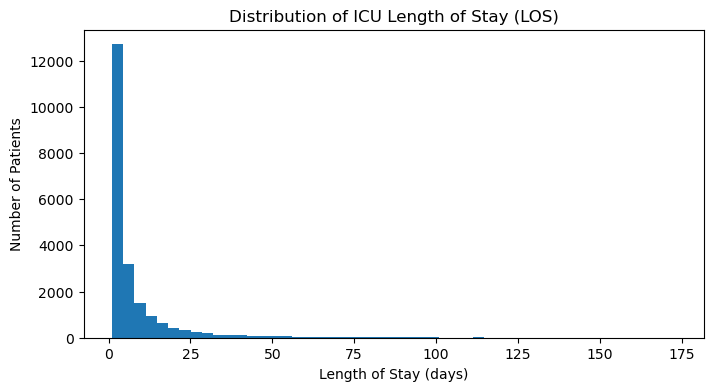

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your final dataset
df = pd.read_csv("icu_model_first24h_enhanced_clean.csv")

# Plot LOS distribution
plt.figure(figsize=(8,4))
plt.hist(df["los"], bins=50)
plt.title("Distribution of ICU Length of Stay (LOS)")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.show()



In [75]:
# def los_group(los):
#     if los < 2:
#         return "VERY SHORT (0–1 days)"
#     elif los < 4:
#         return "SHORT (2–3 days)"
#     elif los < 7:
#         return "MEDIUM (4–6 days)"
#     else:
#         return "LONG (7+ days)"

# df["los_group"] = df["los"].apply(los_group)
# mean_los = df["los"].mean().round(1)  # rounded mean
# df["los_group"] = df["los"].apply(lambda x: "LONG STAY" if x >= mean_los else "SHORT STAY")




In [76]:
# Compute mean LOS and round it
mean_los = df["los"].mean().round(1)
print("Rounded Mean LOS:", mean_los)

# Create los_group based on mean LOS
df["los_group"] = df["los"].apply(
    lambda x: "LONG STAY" if x >= mean_los else "SHORT STAY"
)

# Check distribution
print("\nLOS Group Distribution:")
print(df["los_group"].value_counts())


Rounded Mean LOS: 8.3

LOS Group Distribution:
los_group
SHORT STAY    16154
LONG STAY      5126
Name: count, dtype: int64


In [77]:
import sys
print(sys.executable)

C:\Users\rosha\miniconda3\envs\shap_env\python.exe


In [78]:
import seaborn as sns
print(sns.__version__)

0.13.2


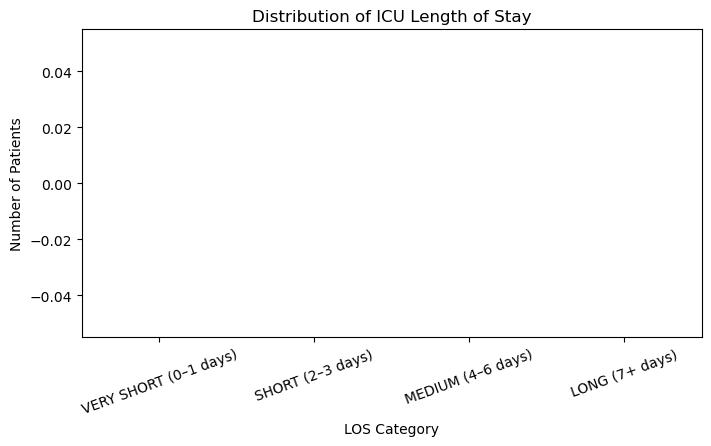

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="los_group", order=[
    "VERY SHORT (0–1 days)",
    "SHORT (2–3 days)",
    "MEDIUM (4–6 days)",
    "LONG (7+ days)"
])
plt.title("Distribution of ICU Length of Stay")
plt.xlabel("LOS Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.show()


In [84]:
import pandas as pd

df = pd.read_csv("icu_model_first24h_enhanced_clean.csv")

# Binary target: long ICU stay (7+ days)
df["y_longstay"] = (df["los"] >= 7).astype(int)

print(df["y_longstay"].value_counts())


y_longstay
0    15329
1     5951
Name: count, dtype: int64


In [86]:
# --- BLOCK 4A: Clean categorical variables ---
df["gender"] = df["gender"].fillna("UNKNOWN")
df["insurance"] = df["insurance"].fillna("UNKNOWN")
df["age_group"] = df["age_group"].fillna("UNKNOWN")
df["ethnicity_grouped"] = df["ethnicity_grouped"].fillna("UNKNOWN")
df["first_careunit"] = df["first_careunit"].fillna("UNKNOWN")

# Columns to one-hot encode
categorical_cols = [
    "gender",
    "ethnicity_grouped",
    "insurance",
    "age_group",
    "first_careunit"
]



In [91]:
#  BLOCK 4B: One-Hot Encode 
df_encoded = pd.get_dummies(
    df,                  # << DO NOT USE df_model
    columns=categorical_cols,
    drop_first=False
)

print("One-hot encoded shape:", df_encoded.shape)
print("Encoded columns example:", df_encoded.columns[:20])


One-hot encoded shape: (21280, 44)
Encoded columns example: Index(['subject_id', 'hadm_id', 'icustay_id', 'intime', 'outtime', 'los',
       'hr_mean24', 'sbp_mean24', 'dbp_mean24', 'resp_mean24', 'temp_mean24',
       'spo2_mean24', 'height_m_mean24', 'weight_kg_mean24', 'bmi_mean24',
       'y_longstay', 'gender_F', 'gender_M', 'gender_UNKNOWN',
       'ethnicity_grouped_ASIAN'],
      dtype='object')


In [93]:
categorical_cols = ["gender", "ethnicity_grouped", "insurance", "age_group","first_careunit" ]

df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=False
)

print("Encoded shape:", df_encoded.shape)
print(df_encoded.head())


Encoded shape: (21280, 40)
   subject_id  hadm_id  icustay_id               intime              outtime  \
0           3   145834      211552  2101-10-20 19:10:11  2101-10-26 20:43:09   
1           8   159514      262299  2117-11-20 12:36:10  2117-11-21 14:24:55   
2           9   150750      220597  2149-11-09 13:07:02  2149-11-14 20:52:14   
3          10   184167      288409  2103-06-28 11:39:05  2103-07-06 13:51:43   
4          11   194540      229441  2178-04-16 06:19:32  2178-04-17 20:21:05   

      los   hr_mean24  sbp_mean24  dbp_mean24  resp_mean24  ...  \
0  6.0646  111.785714   79.316456   42.746835    13.644444  ...   
1  1.0755  138.296296   77.833333   46.833333    18.028175  ...   
2  5.3231   92.500000  159.375000   79.525000    14.369565  ...   
3  8.0921  147.560000   58.800000   36.900000    18.028175  ...   
4  1.5844   84.958333  105.166667   52.541667    18.045455  ...   

   age_group_50-64  age_group_65-89  age_group_90+  age_group_UNKNOWN  \
0            Fal

In [95]:
# Create X (Features)

id_cols = ["subject_id", "hadm_id", "icustay_id", "intime", "outtime"]

X = df_encoded.drop(columns=id_cols + ["los"])

print("X shape:", X.shape)
print("Feature columns:", X.columns.tolist()[:20])


X shape: (21280, 34)
Feature columns: ['hr_mean24', 'sbp_mean24', 'dbp_mean24', 'resp_mean24', 'temp_mean24', 'spo2_mean24', 'height_m_mean24', 'weight_kg_mean24', 'bmi_mean24', 'gender_F', 'gender_M', 'ethnicity_grouped_ASIAN', 'ethnicity_grouped_BLACK', 'ethnicity_grouped_HISPANIC/LATINO', 'ethnicity_grouped_OTHER', 'ethnicity_grouped_UNKNOWN/NOT DISCLOSED', 'ethnicity_grouped_WHITE', 'insurance_Government', 'insurance_Medicaid', 'insurance_Medicare']


In [97]:
#Create y (Target)

y = df_encoded["los"]

print("y shape:", y.shape)
print(y.head())
# Save final files

X.to_csv("X_features_ready.csv", index=False)
y.to_csv("y_los.csv", index=False)
df_encoded.to_csv("icu_model_first24h_final_for_training.csv", index=False)

print("Saved X_features_ready.csv")
print("Saved y_los.csv")
print("Saved icu_model_first24h_final_for_training.csv")



y shape: (21280,)
0    6.0646
1    1.0755
2    5.3231
3    8.0921
4    1.5844
Name: los, dtype: float64
Saved X_features_ready.csv
Saved y_los.csv
Saved icu_model_first24h_final_for_training.csv


In [98]:
# checkng the same kind of value printed earlier 
import pandas as pd

# Load the final encoded dataset
df = pd.read_csv("icu_model_first24h_final_for_training.csv")

print("Shape:", df.shape)
print("Columns (first 15):", df.columns[:15].tolist())
print(df[["los"]].head())


Shape: (21280, 40)
Columns (first 15): ['subject_id', 'hadm_id', 'icustay_id', 'intime', 'outtime', 'los', 'hr_mean24', 'sbp_mean24', 'dbp_mean24', 'resp_mean24', 'temp_mean24', 'spo2_mean24', 'height_m_mean24', 'weight_kg_mean24', 'bmi_mean24']
      los
0  6.0646
1  1.0755
2  5.3231
3  8.0921
4  1.5844


In [99]:
# Compute mean LOS across all ICU stays
# this  mean is the cut-off between “short stay” and “long stay”.
los_mean = df["los"].mean()
print("Mean LOS (days):", los_mean)
los_mean_rounded = round(los_mean)
print(los_mean_rounded)



Mean LOS (days): 8.307046024436088
8


In [101]:
# Create binary target:
# transforming  the continuous LOS into a binary label as required 
# 1 = long stay (LOS >= mean LOS)
# 0 = short stay (LOS < mean LOS)
df["y_longstay"] = (df["los"] >= los_mean).astype(int)

# Inspect a few rows to make sure it makes sense
print(df[["los", "y_longstay"]].head(10))


      los  y_longstay
0  6.0646           0
1  1.0755           0
2  5.3231           0
3  8.0921           0
4  1.5844           0
5  7.6348           0
6  3.6660           0
7  1.3017           0
8  1.0508           0
9  5.9017           0


In [104]:
print("Mean LOS:", df["los"].mean())
los_mean_rounded = round(los_mean)
print(los_mean_rounded)



Mean LOS: 8.307046024436088
8


In [107]:
import pandas as pd

# Load your LOS
los_df = pd.read_csv("y_los.csv")

# Create binary target
mean_los = los_df["los"].mean()
los_df["y_longstay"] = (los_df["los"] >= mean_los).astype(int)

# Save it
los_df[["y_longstay"]].to_csv("y_longstay.csv", index=False)

print("Saved y_longstay.csv")
print(los_df.head())



Saved y_longstay.csv
      los  y_longstay
0  6.0646           0
1  1.0755           0
2  5.3231           0
3  8.0921           0
4  1.5844           0


In [109]:
los_df.y_longstay.value_counts()

y_longstay
0    16157
1     5123
Name: count, dtype: int64

In [111]:
# 3) Shock Index = HR / SBP
#    - High shock index indicates possible circulatory shock.
df["shock_index"] = df["hr_mean24"] / df["sbp_mean24"]

# Avoid infinite or crazy values
df["shock_index"] = df["shock_index"].replace([np.inf, -np.inf], np.nan)
df["shock_index"] = df["shock_index"].clip(lower=0, upper=5)

# 4) Pulse Pressure = SBP - DBP
#    - Low pulse pressure can indicate poor cardiac output.
df["pulse_pressure"] = df["sbp_mean24"] - df["dbp_mean24"]

# 5) Vital sign flag features (0/1)

# Tachycardia: HR >= 100
df["tachycardia"] = (df["hr_mean24"] >= 100).astype(int)

# Hypotension: SBP < 90
df["hypotension"] = (df["sbp_mean24"] < 90).astype(int)

# Tachypnea: Resp >= 22
df["tachypnea"] = (df["resp_mean24"] >= 22).astype(int)

# Hypoxia: SpO2 < 92
df["hypoxia"] = (df["spo2_mean24"] < 92).astype(int)

# Fever: Temp >= 38
df["fever"] = (df["temp_mean24"] >= 38).astype(int)

# Low temperature: Temp < 36
df["low_temp"] = (df["temp_mean24"] < 36).astype(int)

# 6)BMI category —  already had something similar
def bmi_category(bmi):
    if pd.isna(bmi):
        return "UNKNOWN"
    if bmi < 18.5:
        return "UNDERWEIGHT"
    elif bmi < 25:
        return "NORMAL"
    elif bmi < 30:
        return "OVERWEIGHT"
    elif bmi < 35:
        return "OBESE_I"
    elif bmi < 40:
        return "OBESE_II"
    else:
        return "OBESE_III"

df["bmi_class"] = df["bmi_mean24"].apply(bmi_category)

# 7)  LOS group only for description / plots
def los_group(los):
    if los < 2:
        return "VERY SHORT (0–1 days)"
    elif los < 4:
        return "SHORT (2–3 days)"
    elif los < 7:
        return "MEDIUM (4–6 days)"
    else:
        return "LONG (7+ days)"

df["los_group"] = df["los"].apply(los_group)

# 8) Save the feature-engineered dataset
df.to_csv("icu_model_first24h_with_features.csv", index=False)
print("Saved: icu_model_first24h_with_features.csv")
print("New columns added:")
print([c for c in df.columns if c not in [
    "subject_id","hadm_id","icustay_id","intime","outtime",
    "los","gender","ethnicity_grouped","age_group","insurance",
    "first_careunit","hr_mean24","sbp_mean24","dbp_mean24",
    "resp_mean24","temp_mean24","spo2_mean24","height_m_mean24",
    "weight_kg_mean24","bmi_mean24"
]])


Saved: icu_model_first24h_with_features.csv
New columns added:
['gender_F', 'gender_M', 'ethnicity_grouped_ASIAN', 'ethnicity_grouped_BLACK', 'ethnicity_grouped_HISPANIC/LATINO', 'ethnicity_grouped_OTHER', 'ethnicity_grouped_UNKNOWN/NOT DISCLOSED', 'ethnicity_grouped_WHITE', 'insurance_Government', 'insurance_Medicaid', 'insurance_Medicare', 'insurance_Private', 'insurance_Self Pay', 'age_group_0-17', 'age_group_18-49', 'age_group_50-64', 'age_group_65-89', 'age_group_90+', 'age_group_UNKNOWN', 'first_careunit_CCU', 'first_careunit_CSRU', 'first_careunit_MICU', 'first_careunit_NICU', 'first_careunit_SICU', 'first_careunit_TSICU', 'y_longstay', 'shock_index', 'pulse_pressure', 'tachycardia', 'hypotension', 'tachypnea', 'hypoxia', 'fever', 'low_temp', 'bmi_class', 'los_group']


This is because the main goal is to early identify patients who will require long ICU stays.
High recall ensures we catch most long-stay patients, which is crucial for hospital resource planning, bed management, and personnel allocation.
Accuracy and precision are less important because the dataset is imbalanced and missing long-stay patients (false negatives) is far more harmful than predicting a few extra long-stay cases (false positives).
This is why the tuned XGBoost model—with the highest recall—is the most suitable model for our condition

In [114]:
X.isna().sum().sum()


np.int64(0)

In [116]:
X.isna().sum().sort_values(ascending=False).head(10)


hr_mean24           0
sbp_mean24          0
dbp_mean24          0
resp_mean24         0
temp_mean24         0
spo2_mean24         0
height_m_mean24     0
weight_kg_mean24    0
bmi_mean24          0
gender_F            0
dtype: int64

In [118]:
X.select_dtypes(include=['object', 'string']).columns


Index([], dtype='object')

In [120]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(col, X[col].unique()[:10])


In [122]:
X.describe().T


,count,mean,std,min,25%,50%,75%,max
hr_mean24,21280.0,96.189661,25.115073,35.750000,78.440508,89.877500,108.313920,195.565217
sbp_mean24,21280.0,102.747868,27.653683,50.000000,77.214286,105.880000,122.479066,191.761905
dbp_mean24,21280.0,50.902476,13.801863,20.880000,39.160386,50.641429,60.555556,126.960000
resp_mean24,21280.0,18.544764,3.807088,5.269231,16.310140,18.028175,20.120000,42.437500
temp_mean24,21280.0,36.672082,0.887787,30.000000,36.262500,36.722227,37.166666,39.905980
spo2_mean24,21280.0,96.568926,2.689326,50.279412,96.029412,96.655826,97.412938,100.000000
height_m_mean24,21280.0,1.741280,0.022754,1.625600,1.727200,1.727200,1.778000,1.778000
weight_kg_mean24,21280.0,77.749335,16.422056,20.667003,76.315973,76.315973,76.315973,300.000000
bmi_mean24,21280.0,25.638955,5.373084,6.927751,24.140815,25.581746,25.581746,94.898149


In [124]:
X.shape, y.shape


((21280, 34), (21280,))

In [126]:
import pandas as pd

X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSample y values:")
print(y.value_counts())


X shape: (21280, 34)
y shape: (21280,)

Sample y values:
y_longstay
0    16157
1     5123
Name: count, dtype: int64


In [127]:
#starting the 1st model for modelling with logistic regression (the baseline model )
print(" Importing libraries...")
import numpy as np
import random
np.random.seed(42)
random.seed(42)
import os
os.environ["PYTHONHASHSEED"] = "42"
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score    # <-- NEW
)




 Importing libraries...


In [129]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []  # store all models here

In [132]:
print(" Loading cleaned feature and target files...")

X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Preview X:")
print(X.head())
print("Preview y:")
print(y.head())


 Loading cleaned feature and target files...
X shape: (21280, 34)
y shape: (21280,)
Preview X:
    hr_mean24  sbp_mean24  dbp_mean24  resp_mean24  temp_mean24  spo2_mean24  \
0  111.785714   79.316456   42.746835    13.644444    37.002881    97.870968   
1  138.296296   77.833333   46.833333    18.028175    34.377779    96.655826   
2   92.500000  159.375000   79.525000    14.369565    37.049391    97.650000   
3  147.560000   58.800000   36.900000    18.028175    36.279999    96.655826   
4   84.958333  105.166667   52.541667    18.045455    36.805545    96.500000   

   height_m_mean24  weight_kg_mean24  bmi_mean24  gender_F  ...  \
0           1.7780         96.095655   30.397666     False  ...   
1           1.7272         76.315973   25.581746     False  ...   
2           1.7272        104.000000   34.861661     False  ...   
3           1.7272         76.315973   25.581746     False  ...   
4           1.7272         76.315973   25.581746     False  ...   

   age_group_50-64  a

In [134]:
print(" Splitting into training (70%) and testing (30%)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


 Splitting into training (70%) and testing (30%)...
Training shape: (14896, 34)
Testing shape: (6384, 34)


In [136]:
print(" Scaling numeric features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


 Scaling numeric features...
Scaling completed.


In [138]:
print(" Training Logistic Regression baseline model...")

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

print("Model training completed.")


 Training Logistic Regression baseline model...
Model training completed.


In [140]:
print(" Making predictions and evaluating...")

y_pred = log_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
from sklearn.metrics import balanced_accuracy_score

bal_acc = balanced_accuracy_score(y_test, y_pred)
print("overall Balanced Accuracy:", bal_acc)



 Making predictions and evaluating...

Accuracy: 0.7949561403508771

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4847
           1       0.62      0.39      0.48      1537

    accuracy                           0.79      6384
   macro avg       0.72      0.66      0.68      6384
weighted avg       0.78      0.79      0.78      6384


Confusion Matrix:
[[4476  371]
 [ 938  599]]
overall Balanced Accuracy: 0.6565890215882518


In [143]:
# model 2 random forest
print("Importing libraries for Random Forest...")


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


Importing libraries for Random Forest...


In [145]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []  # store all models here

In [147]:
# Load data + train/test split (70/30 as used before )
print("Loading X and y for Random Forest...")

X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSplitting train/test (70/30, stratified)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Loading X and y for Random Forest...
X shape: (21280, 34)
y shape: (21280,)

Splitting train/test (70/30, stratified)...
Train shape: (14896, 34)
Test shape: (6384, 34)


In [149]:
from sklearn.utils import resample

# Combine X and y for downsampling
train_df = pd.concat([X_train, y_train], axis=1)

target_col = "y_longstay"

majority = train_df[train_df[target_col] == 0]
minority = train_df[train_df[target_col] == 1]

# Upsample minority to match majority
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

downsampled_df = pd.concat([majority, minority_upsampled])

X_train_ds = downsampled_df.drop(columns=[target_col])
y_train_ds = downsampled_df[target_col]

In [151]:
# training the model
print("\nTraining Random Forest model...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")



Training Random Forest model...
Random Forest training complete.


In [152]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


In [153]:
# Evaluate Random Forest
print("\nMaking predictions and evaluating Random Forest...")

y_pred = rf_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\nRANDOM FOREST RESULTS ")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", bal_acc)





Making predictions and evaluating Random Forest...

RANDOM FOREST RESULTS 
Accuracy : 0.8020
Precision: 0.6862
Recall   : 0.3273
F1-score : 0.4432

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4847
           1       0.69      0.33      0.44      1537

    accuracy                           0.80      6384
   macro avg       0.75      0.64      0.66      6384
weighted avg       0.79      0.80      0.77      6384

Confusion Matrix:
[[4617  230]
 [1034  503]]
Balanced Accuracy: 0.6399044328340519


In [154]:
# Feature importance (which variables matter most?)
print("\nTop 15 most important features:")

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(15))



Top 15 most important features:
hr_mean24                                  0.155616
temp_mean24                                0.129956
sbp_mean24                                 0.127718
dbp_mean24                                 0.122718
resp_mean24                                0.085691
spo2_mean24                                0.082235
bmi_mean24                                 0.052786
weight_kg_mean24                           0.049047
first_careunit_NICU                        0.036534
ethnicity_grouped_WHITE                    0.012353
insurance_Private                          0.011285
insurance_Medicare                         0.010764
first_careunit_CSRU                        0.010075
ethnicity_grouped_UNKNOWN/NOT DISCLOSED    0.009247
first_careunit_MICU                        0.009100
dtype: float64


In [160]:
# model 3 gradiant modelling 
print(" Importing libraries for Gradient Boosting...")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


 Importing libraries for Gradient Boosting...


In [162]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []  # store all models here

In [164]:
# Load data + split (same as before, 70/30)
print(" Loading data and splitting (70/30)...")

X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


 Loading data and splitting (70/30)...
X shape: (21280, 34)
y shape: (21280,)
Train shape: (14896, 34)
Test shape: (6384, 34)


In [166]:
# print("TRAIN SET:")
# print(y_train.value_counts())

# print("\nTEST SET:")
# print(y_test.value_counts())

In [168]:
from sklearn.utils import resample

# Combine X and y for downsampling
train_df = pd.concat([X_train, y_train], axis=1)

target_col = "y_longstay"

majority = train_df[train_df[target_col] == 0]
minority = train_df[train_df[target_col] == 1]

# Upsample minority to match majority
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

downsampled_df = pd.concat([majority, minority_upsampled])

X_train_ds = downsampled_df.drop(columns=[target_col])
y_train_ds = downsampled_df[target_col]

In [170]:
# Train Gradient Boosting Classifier
print("\nTraining Gradient Boosting Classifier...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,    # number of trees
    learning_rate=0.05, # step size (small = more stable)
    max_depth=3,        # depth of each tree
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting training complete.")



Training Gradient Boosting Classifier...
Gradient Boosting training complete.


In [171]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


In [174]:
# Evaluate Gradient Boosting
print("\n Making predictions and evaluating Gradient Boosting...")

y_pred = gb_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n GRADIENT BOOSTING RESULTS")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", bal_acc)





 Making predictions and evaluating Gradient Boosting...

 GRADIENT BOOSTING RESULTS
Accuracy : 0.8048
Precision: 0.6948
Recall   : 0.3377
F1-score : 0.4545

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4847
           1       0.69      0.34      0.45      1537

    accuracy                           0.80      6384
   macro avg       0.76      0.65      0.67      6384
weighted avg       0.79      0.80      0.78      6384

Confusion Matrix:
[[4619  228]
 [1018  519]]
Balanced Accuracy: 0.6453156907149269


In [177]:
print("\n Top 15 most important features (Gradient Boosting):")

importances_gb = pd.Series(gb_model.feature_importances_, index=X.columns)
print(importances_gb.sort_values(ascending=False).head(15))



 Top 15 most important features (Gradient Boosting):
hr_mean24               0.532856
temp_mean24             0.109301
sbp_mean24              0.097343
dbp_mean24              0.079316
first_careunit_NICU     0.055240
resp_mean24             0.030105
spo2_mean24             0.026400
bmi_mean24              0.012049
weight_kg_mean24        0.010280
first_careunit_CSRU     0.008652
insurance_Private       0.007553
first_careunit_SICU     0.007518
first_careunit_TSICU    0.005783
first_careunit_MICU     0.002459
first_careunit_CCU      0.002325
dtype: float64


In [180]:

!pip install xgboost


In [181]:
print(" Importing XGBoost and metrics...")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


 Importing XGBoost and metrics...


In [3157]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []  # store all models here

In [184]:
# Load data and split 
print(": Loading data and splitting (70/30)...")

X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)




: Loading data and splitting (70/30)...
X shape: (21280, 34)
y shape: (21280,)
Train shape: (14896, 34)
Test shape: (6384, 34)


In [186]:
# Define and train XGBoost (baseline)
print("\nStep 3: Training XGBoost Classifier (baseline)...")

xgb_model = XGBClassifier(
    n_estimators=300,        # number of trees
    learning_rate=0.05,     # step size
    max_depth=4,            # tree depth
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])  # handle imbalance
)

xgb_model.fit(X_train, y_train)

print("XGBoost training complete.")



Step 3: Training XGBoost Classifier (baseline)...
XGBoost training complete.


In [188]:
from sklearn.utils import resample

# Combine X and y for downsampling
train_df = pd.concat([X_train, y_train], axis=1)

target_col = "y_longstay"

majority = train_df[train_df[target_col] == 0]
minority = train_df[train_df[target_col] == 1]

# Upsample minority to match majority
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

downsampled_df = pd.concat([majority, minority_upsampled])

X_train_ds = downsampled_df.drop(columns=[target_col])
y_train_ds = downsampled_df[target_col]

In [190]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


In [192]:
# Evaluate XG boost
print(" Making predictions and evaluating XGBoost...")

y_pred = xgb_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(" XGBOOST RESULTS ")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", bal_acc)



 Making predictions and evaluating XGBoost...
 XGBOOST RESULTS 
Accuracy : 0.7472
Precision: 0.4792
Recall   : 0.5777
F1-score : 0.5239

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      4847
           1       0.48      0.58      0.52      1537

    accuracy                           0.75      6384
   macro avg       0.67      0.69      0.68      6384
weighted avg       0.77      0.75      0.75      6384

Confusion Matrix:
[[3882  965]
 [ 649  888]]
Balanced Accuracy: 0.689328319712681


In [194]:
print("Evaluating ORIGINAL XGBoost predictions (thr=0.50)...")

y_pred_original = xgb_model.predict(X_test)

results.append(
    evaluate_model("XGB (Original, thr=0.50)", y_test, y_pred_original)
)

print(evaluate_model("XGB (Original, thr=0.50)", y_test, y_pred_original))

Evaluating ORIGINAL XGBoost predictions (thr=0.50)...
{'Model': 'XGB (Original, thr=0.50)', 'Accuracy': 0.7471804511278195, 'Balanced Accuracy': 0.689328319712681, 'Recall (Long Stay)': 0.5777488614183475, 'Precision': 0.47922288181327577, 'F1-score': 0.5238938053097345}


In [197]:
print("\nStep 5: Top 15 most important features (XGBoost):")

importances_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
print(importances_xgb.sort_values(ascending=False).head(15))



Step 5: Top 15 most important features (XGBoost):
first_careunit_NICU     0.618449
hr_mean24               0.039068
first_careunit_CSRU     0.023650
first_careunit_SICU     0.019165
insurance_Private       0.018560
temp_mean24             0.015349
sbp_mean24              0.014977
first_careunit_CCU      0.014827
first_careunit_TSICU    0.014802
resp_mean24             0.013275
dbp_mean24              0.012760
spo2_mean24             0.012435
insurance_Medicare      0.011985
bmi_mean24              0.011346
insurance_Self Pay      0.011265
dtype: float32


In [199]:
# trying the hyperparameter tuning for better results 
import pandas as pd
from sklearn.model_selection import train_test_split

# Load feature matrix and labels
X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Shapes:", X_train.shape, X_test.shape)


Shapes: (14896, 34) (6384, 34)


In [201]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []  # store all models here

In [203]:
# # trying the hyperparameter tuning for better results 
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings("ignore")
print("Libraries imported.")
 

Libraries imported.


In [205]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42     # <-- important
)


In [207]:
from sklearn.utils import resample

# Combine X and y for downsampling
train_df = pd.concat([X_train, y_train], axis=1)

target_col = "y_longstay"

majority = train_df[train_df[target_col] == 0]
minority = train_df[train_df[target_col] == 1]

# Upsample minority to match majority
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

downsampled_df = pd.concat([majority, minority_upsampled])

X_train_ds = downsampled_df.drop(columns=[target_col])
y_train_ds = downsampled_df[target_col]

In [209]:
# Define Fast Tuning Parameter Grid
# Parameter search space
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "scale_pos_weight": [3, 4, 5]   # handling class imbalance
}

# Base model
xgb_base = XGBClassifier(eval_metric="logloss")
print("Parameter grid defined.")


Parameter grid defined.


In [211]:
# Running  RandomizedSearchCV (Fast Tuning)
# Tuner setup
tuner = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,             # fast tuning
    scoring="recall",      # we want to improve recall
    cv=3,
    verbose=1,
    n_jobs=-1,              # use all CPU cores
     # random_state=42, 
)

# Run tuning
print("Starting tuning...")
tuner.fit(X_train, y_train)

print("Best parameters found:")
print(tuner.best_params_)


Starting tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found:
{'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [212]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


In [213]:
# Evaluate the Tuned XGBoost Model
# Select the best model from tuning
best_xgb = tuner.best_estimator_

# Make predictions on test set
y_pred = best_xgb.predict(X_test)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nTuned XGBoost Results")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", bal_acc)



Tuned XGBoost Results
Accuracy : 0.6455200501253133
Precision: 0.3778600269179004
Recall   : 0.730644111906311
F1 Score : 0.4981148813484143

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.62      0.73      4847
           1       0.38      0.73      0.50      1537

    accuracy                           0.65      6384
   macro avg       0.63      0.67      0.61      6384
weighted avg       0.76      0.65      0.67      6384

Confusion Matrix:
[[2998 1849]
 [ 414 1123]]
Balanced Accuracy: 0.6745855178883731


In [217]:
import pandas as pd

df_original = pd.read_csv("results_original.csv")
print(df_original.head())

                 Model    Recall  Precision        F1  Balanced Accuracy
0  Logistic Regression  0.393122   0.605400  0.476697           0.657793
1        Random Forest  0.346595   0.649810  0.452067           0.645038
2    Gradient Boosting  0.345920   0.670588  0.456406           0.647251
3              XGBoost  0.364127   0.635294  0.462923           0.650437
4        Tuned XGBoost  0.741740   0.363757  0.488130           0.674583


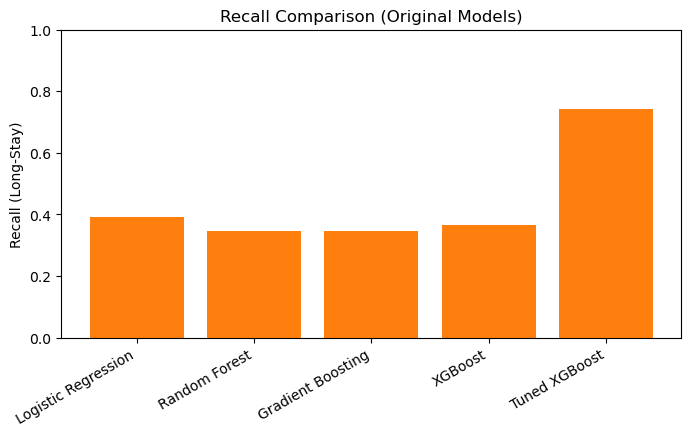

In [222]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(df_original["Model"], df_original["Recall"], color="#ff7f0e")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Recall (Long-Stay)")
plt.title("Recall Comparison (Original Models)")
plt.ylim(0, 1)
plt.show()


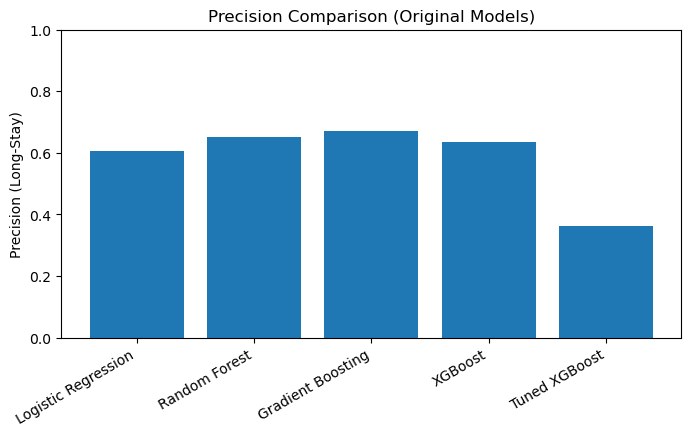

In [224]:
plt.figure(figsize=(8,4))
plt.bar(df_original["Model"], df_original["Precision"], color="#1f77b4")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Precision (Long-Stay)")
plt.title("Precision Comparison (Original Models)")
plt.ylim(0, 1)
plt.show()


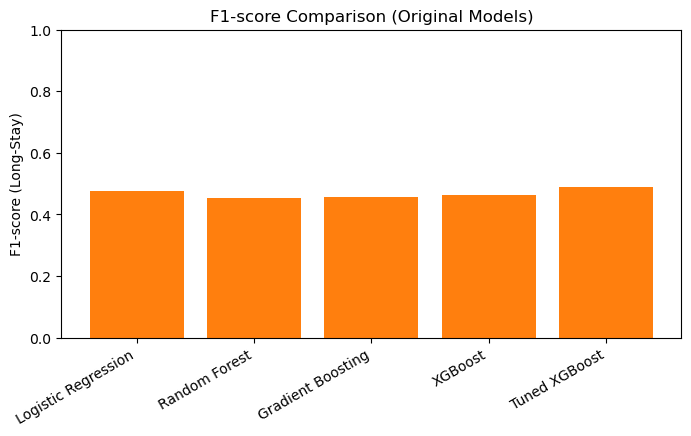

In [226]:
plt.figure(figsize=(8,4))
plt.bar(df_original["Model"], df_original["F1"], color="#ff7f0e")
plt.xticks(rotation=30, ha="right")
plt.ylabel("F1-score (Long-Stay)")
plt.title("F1-score Comparison (Original Models)")
plt.ylim(0, 1)
plt.show()


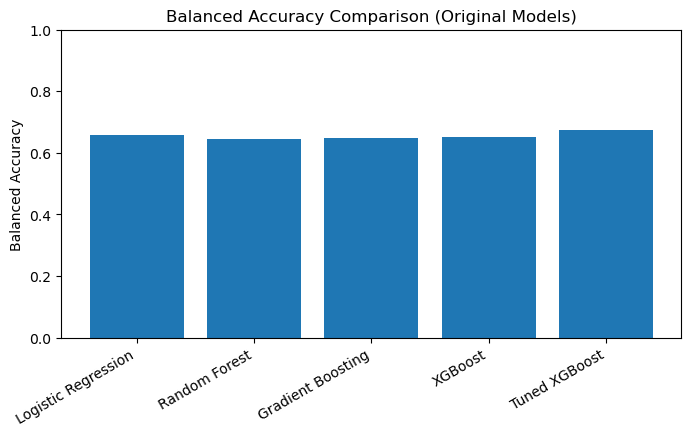

In [228]:
plt.figure(figsize=(8,4))
plt.bar(df_original["Model"], df_original["Balanced Accuracy"], color="#1f77b4")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy Comparison (Original Models)")
plt.ylim(0, 1)
plt.show()


In [230]:
import matplotlib
print(matplotlib.__version__)


3.10.8



Top 20 Most Important Features:
                 feature  importance
31   first_careunit_NICU    0.487378
0              hr_mean24    0.067993
29   first_careunit_CSRU    0.030874
32   first_careunit_SICU    0.023436
1             sbp_mean24    0.021087
20     insurance_Private    0.021055
4            temp_mean24    0.020351
2             dbp_mean24    0.019899
33  first_careunit_TSICU    0.019094
28    first_careunit_CCU    0.017670
30   first_careunit_MICU    0.016612
3            resp_mean24    0.016339
5            spo2_mean24    0.015249
10              gender_M    0.014387
8             bmi_mean24    0.014348
19    insurance_Medicare    0.013771
7       weight_kg_mean24    0.013653
23       age_group_18-49    0.013133
24       age_group_50-64    0.012951
6        height_m_mean24    0.012709


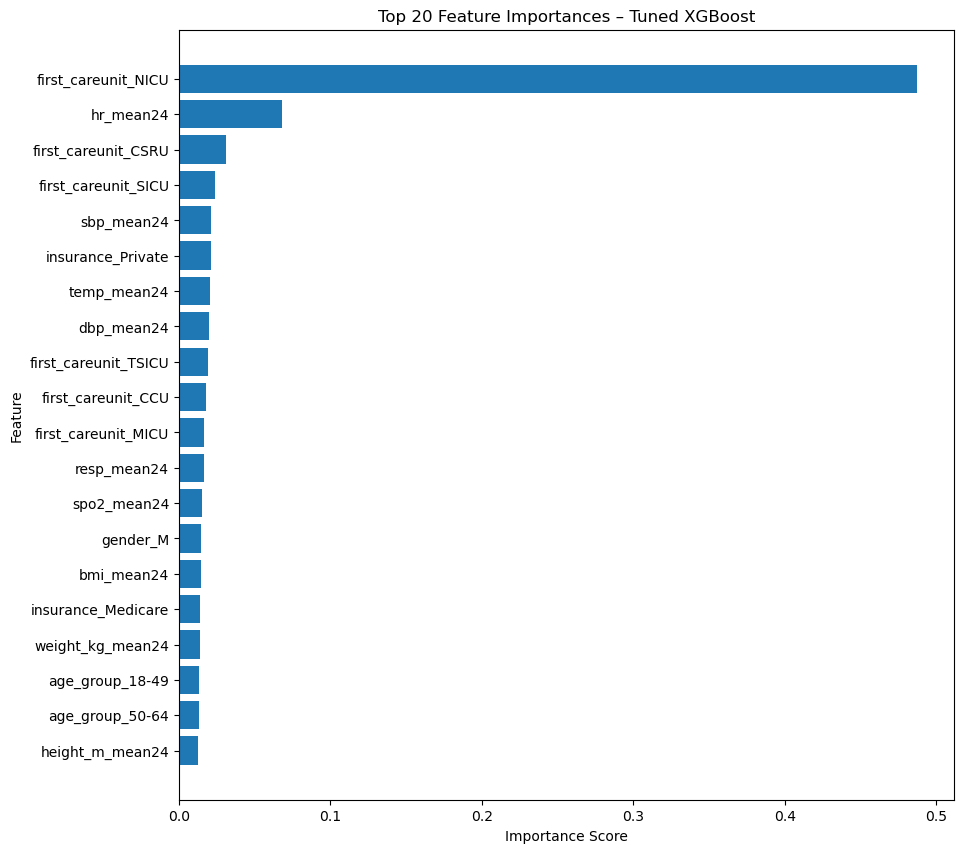

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Load final cleaned data
X = pd.read_csv("X_features_ready.csv")
y = pd.read_csv("y_longstay.csv")["y_longstay"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Tuned XGBoost Model
xgb_tuned = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

# Get feature importance
importance_values = xgb_tuned.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance_values
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20))

# Plot
plt.figure(figsize=(10, 10))
plt.barh(importance_df["feature"].head(20),
         importance_df["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances – Tuned XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [234]:
# STEP 2.1 — Create downsampled training data

SEED = 42

def downsample_train_safe(Xtr, ytr, random_state=42):
    df = Xtr.copy().reset_index(drop=True)
    ytr = pd.Series(ytr).reset_index(drop=True)

    df["__target__"] = ytr.values

    maj = df[df["__target__"] == 0]
    mino = df[df["__target__"] == 1]

    n = min(len(maj), len(mino))
    maj_down = maj.sample(n=n, random_state=random_state)
    mino_down = mino.sample(n=n, random_state=random_state)

    df_bal = pd.concat([maj_down, mino_down]).sample(frac=1, random_state=random_state)

    X_bal = df_bal.drop(columns="__target__")
    y_bal = df_bal["__target__"].astype(int)

    return X_bal, y_bal

X_train_down, y_train_down = downsample_train_safe(X_train, y_train, random_state=SEED)

print("Downsampled class distribution:")
print(y_train_down.value_counts())


Downsampled class distribution:
__target__
0    3586
1    3586
Name: count, dtype: int64


In [236]:
# print("Train shape:", X_train.shape)
# print("Test shape:", X_test.shape)


In [238]:

# LOGISTIC REGRESSION – DOWNSAMPLED
#
print("\n")
print("LOGISTIC REGRESSION – DOWNSAMPLED")
print("")

# Scale downsampled training + same test
scaler_lr_down = StandardScaler()
X_train_lr_down = scaler_lr_down.fit_transform(X_train_down)
X_test_lr_down = scaler_lr_down.transform(X_test)

log_model_down = LogisticRegression(max_iter=2000)
log_model_down.fit(X_train_lr_down, y_train_down)

y_pred_lr_down = log_model_down.predict(X_test_lr_down)

acc_d = accuracy_score(y_test, y_pred_lr_down)
bal_acc_d = balanced_accuracy_score(y_test, y_pred_lr_down)
rec_d = recall_score(y_test, y_pred_lr_down)
prec_d = precision_score(y_test, y_pred_lr_down)
f1_d = f1_score(y_test, y_pred_lr_down)

print(f"Accuracy          : {acc_d:.4f}")
print(f"Balanced Accuracy : {bal_acc_d:.4f}")
print(f"Recall (Long stay): {rec_d:.4f}")
print(f"Precision         : {prec_d:.4f}")
print(f"F1-score          : {f1_d:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_down))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_down))





LOGISTIC REGRESSION – DOWNSAMPLED

Accuracy          : 0.7287
Balanced Accuracy : 0.6725
Recall (Long stay): 0.5641
Precision         : 0.4495
F1-score          : 0.5003

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      4847
           1       0.45      0.56      0.50      1537

    accuracy                           0.73      6384
   macro avg       0.65      0.67      0.66      6384
weighted avg       0.75      0.73      0.74      6384

Confusion Matrix:
[[3785 1062]
 [ 670  867]]


In [240]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (Long Stay)": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []  # store all models here

In [242]:



#  DOWN-SAMPLED TRAINING

print("\n RANDOM FOREST – DOWNSAMPLED TRAINING DATA")
rf_model_down = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight=None   # IMPORTANT: no class_weight now, data is balanced
)

rf_model_down.fit(X_train_down, y_train_down)

y_pred_rf_down = rf_model_down.predict(X_test)

acc_d = accuracy_score(y_test, y_pred_rf_down)
rec_d = recall_score(y_test, y_pred_rf_down)
prec_d = precision_score(y_test, y_pred_rf_down)
f1_d = f1_score(y_test, y_pred_rf_down)
bal_acc_d = balanced_accuracy_score(y_test, y_pred_rf_down)

print(f"Accuracy          : {acc_d:.4f}")
print(f"Recall (long stay): {rec_d:.4f}")
print(f"Precision         : {prec_d:.4f}")
print(f"F1-score          : {f1_d:.4f}")
print(f"Balanced Accuracy : {bal_acc_d:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_down))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_down))




 RANDOM FOREST – DOWNSAMPLED TRAINING DATA
Accuracy          : 0.7260
Recall (long stay): 0.6005
Precision         : 0.4485
F1-score          : 0.5135
Balanced Accuracy : 0.6832

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      4847
           1       0.45      0.60      0.51      1537

    accuracy                           0.73      6384
   macro avg       0.65      0.68      0.66      6384
weighted avg       0.76      0.73      0.74      6384

Confusion Matrix:
[[3712 1135]
 [ 614  923]]


In [245]:


# GRADIENT BOOSTING – DOWNSAMPLED

print("\n")
print("GRADIENT BOOSTING – DOWNSAMPLED")
print("")

gb_model_down = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model_down.fit(X_train_down, y_train_down)

y_pred_gb_down = gb_model_down.predict(X_test)

acc_d = accuracy_score(y_test, y_pred_gb_down)
bal_acc_d = balanced_accuracy_score(y_test, y_pred_gb_down)
rec_d = recall_score(y_test, y_pred_gb_down)
prec_d = precision_score(y_test, y_pred_gb_down)
f1_d = f1_score(y_test, y_pred_gb_down)

print(f"Accuracy          : {acc_d:.4f}")
print(f"Balanced Accuracy : {bal_acc_d:.4f}")
print(f"Recall (Long stay): {rec_d:.4f}")
print(f"Precision         : {prec_d:.4f}")
print(f"F1-score          : {f1_d:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_down))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb_down))





GRADIENT BOOSTING – DOWNSAMPLED

Accuracy          : 0.7303
Balanced Accuracy : 0.6926
Recall (Long stay): 0.6200
Precision         : 0.4558
F1-score          : 0.5254

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      4847
           1       0.46      0.62      0.53      1537

    accuracy                           0.73      6384
   macro avg       0.66      0.69      0.67      6384
weighted avg       0.77      0.73      0.74      6384

Confusion Matrix:
[[3709 1138]
 [ 584  953]]


In [246]:

# XGBOOST – DOWNSAMPLED
# 
print("\n")
print("XGBOOST – DOWNSAMPLED TRAINING")
print("")

xgb_model_down = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=1  # IMPORTANT: no imbalance weight for balanced data
)
xgb_model_down.fit(X_train_down, y_train_down)

y_pred_xgb_down = xgb_model_down.predict(X_test)

acc_d = accuracy_score(y_test, y_pred_xgb_down)
bal_acc_d = balanced_accuracy_score(y_test, y_pred_xgb_down)
rec_d = recall_score(y_test, y_pred_xgb_down)
prec_d = precision_score(y_test, y_pred_xgb_down)
f1_d = f1_score(y_test, y_pred_xgb_down)

print(f"Accuracy          : {acc_d:.4f}")
print(f"Balanced Accuracy : {bal_acc_d:.4f}")
print(f"Recall (Long stay): {rec_d:.4f}")
print(f"Precision         : {prec_d:.4f}")
print(f"F1-score          : {f1_d:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_down))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_down))





XGBOOST – DOWNSAMPLED TRAINING

Accuracy          : 0.7223
Balanced Accuracy : 0.6903
Recall (Long stay): 0.6285
Precision         : 0.4456
F1-score          : 0.5215

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80      4847
           1       0.45      0.63      0.52      1537

    accuracy                           0.72      6384
   macro avg       0.66      0.69      0.66      6384
weighted avg       0.76      0.72      0.74      6384

Confusion Matrix:
[[3645 1202]
 [ 571  966]]


In [249]:

# TUNED XGBOOST – DOWNSAMPLED

print("\n")
print("TUNED XGBOOST – DOWNSAMPLED")
print("")

xgb_tuned_down = XGBClassifier(
    **best_xgb.get_params()
)
# overwrite scale_pos_weight for downsampled case:
if "scale_pos_weight" in xgb_tuned_down.get_params():
    xgb_tuned_down.set_params(scale_pos_weight=1)

xgb_tuned_down.fit(X_train_down, y_train_down)

y_pred_xgb_tuned_down = xgb_tuned_down.predict(X_test)

acc_d = accuracy_score(y_test, y_pred_xgb_tuned_down)
bal_acc_d = balanced_accuracy_score(y_test, y_pred_xgb_tuned_down)
rec_d = recall_score(y_test, y_pred_xgb_tuned_down)
prec_d = precision_score(y_test, y_pred_xgb_tuned_down)
f1_d = f1_score(y_test, y_pred_xgb_tuned_down)

print(f"Accuracy          : {acc_d:.4f}")
print(f"Balanced Accuracy : {bal_acc_d:.4f}")
print(f"Recall (Long stay): {rec_d:.4f}")
print(f"Precision         : {prec_d:.4f}")
print(f"F1-score          : {f1_d:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned_down))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned_down))





TUNED XGBOOST – DOWNSAMPLED

Accuracy          : 0.7267
Balanced Accuracy : 0.6894
Recall (Long stay): 0.6174
Precision         : 0.4506
F1-score          : 0.5210

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      4847
           1       0.45      0.62      0.52      1537

    accuracy                           0.73      6384
   macro avg       0.66      0.69      0.66      6384
weighted avg       0.76      0.73      0.74      6384

Confusion Matrix:
[[3690 1157]
 [ 588  949]]


In [252]:
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42

X = pd.read_csv("X_features_ready.csv")
y_los = pd.read_csv("y_los.csv")["los"]   # <-- confirm column name is 'los'


In [254]:
print(pd.read_csv("y_los.csv").columns)


Index(['los'], dtype='object')


In [256]:
X_train, X_test, los_train, los_test = train_test_split(
    X,
    y_los,
    test_size=0.30,
    random_state=42
)


In [258]:
mean_los = los_train.mean()
print("Mean ICU LOS (training):", mean_los)


Mean ICU LOS (training): 8.383553806390978


In [260]:
y_train = (los_train >= mean_los).astype(int)
y_test  = (los_test  >= mean_los).astype(int)


In [262]:
print("Train label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))


Train label distribution:
los
0    0.757854
1    0.242146
Name: proportion, dtype: float64

Test label distribution:
los
0    0.767701
1    0.232299
Name: proportion, dtype: float64


In [264]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score
)


In [266]:
def get_metrics(y_true, y_pred):
    return {
        "Recall": recall_score(y_true, y_pred),          # long stay = class 1
        "Precision": precision_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }


In [268]:
SEED = 42

models_original = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=1
    )
}


In [270]:
results_original = []

for model_name, model in models_original.items():
    print(f"Training {model_name} (ORIGINAL)")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    row = {"Model": model_name}
    row.update(get_metrics(y_test, y_pred))
    results_original.append(row)


Training Logistic Regression (ORIGINAL)
Training Random Forest (ORIGINAL)
Training Gradient Boosting (ORIGINAL)
Training XGBoost (ORIGINAL)


In [272]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "scale_pos_weight": [3, 4, 5]
}

tuner_orig = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="recall",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

tuner_orig.fit(X_train, y_train)
best_xgb_orig = tuner_orig.best_estimator_

print("Best params (ORIGINAL):", tuner_orig.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params (ORIGINAL): {'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [274]:
y_pred_tuned_orig = best_xgb_orig.predict(X_test)

row = {
    "Model": "Tuned XGBoost",
    **get_metrics(y_test, y_pred_tuned_orig)
}

df_original = pd.concat(
    [df_original, pd.DataFrame([row])],
    ignore_index=True
).drop_duplicates(subset=["Model"], keep="last")

df_original.round(3)

,Model,Recall,Precision,F1,Balanced Accuracy
0,Logistic Regression,0.393,0.605,0.477,0.658
1,Random Forest,0.347,0.650,0.452,0.645
2,Gradient Boosting,0.346,0.671,0.456,0.647
3,XGBoost,0.364,0.635,0.463,0.650
5,Tuned XGBoost,0.742,0.364,0.488,0.675


In [276]:
df_original.to_csv("results_original.csv", index=False)


In [278]:
df_original = pd.read_csv("results_original.csv")


In [280]:
SEED = 42

def downsample_train(Xtr, ytr, random_state=42):
    df = Xtr.copy()
    df["y"] = ytr.values if hasattr(ytr, "values") else ytr

    maj = df[df["y"] == 0]
    mino = df[df["y"] == 1]

    maj_down = maj.sample(n=len(mino), random_state=random_state)
    df_bal = pd.concat([maj_down, mino]).sample(frac=1, random_state=random_state)

    X_bal = df_bal.drop(columns=["y"])
    y_bal = df_bal["y"]
    return X_bal, y_bal

X_train_down, y_train_down = downsample_train(X_train, y_train, random_state=SEED)

print("Train distribution BEFORE downsampling:")
print(y_train.value_counts(normalize=True))

print("\nTrain distribution AFTER downsampling:")
print(y_train_down.value_counts(normalize=True))


Train distribution BEFORE downsampling:
los
0    0.757854
1    0.242146
Name: proportion, dtype: float64

Train distribution AFTER downsampling:
y
0    0.5
1    0.5
Name: proportion, dtype: float64


In [283]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score


# Helper function for metrics

def get_metrics(y_true, y_pred):
    return {
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }


# Base downsampled models

models_down = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=1,
        scale_pos_weight=1   # balanced training
    )
}


# Add Tuned XGBoost (Downsampled)

params_down = tuner_orig.best_params_.copy()
params_down.pop("scale_pos_weight", None)   # remove conflicting param

models_down["Tuned XGBoost (Downsampled)"] = XGBClassifier(
    **params_down,
    eval_metric="logloss",
    random_state=42,
    n_jobs=1,
    scale_pos_weight=1
)


# Train + Evaluate all downsampled models

results_down = []
down_predictions = {}

for model_name, model in models_down.items():
    print(f"Training {model_name} (DOWNSAMPLED)")

    model.fit(X_train_down, y_train_down)
    y_pred = model.predict(X_test)

    down_predictions[model_name] = y_pred

    row = {"Model": model_name}
    row.update(get_metrics(y_test, y_pred))
    results_down.append(row)

df_down = pd.DataFrame(results_down)
df_down.round(3)

Training Logistic Regression (DOWNSAMPLED)
Training Random Forest (DOWNSAMPLED)
Training Gradient Boosting (DOWNSAMPLED)
Training XGBoost (DOWNSAMPLED)
Training Tuned XGBoost (Downsampled) (DOWNSAMPLED)


,Model,Recall,Precision,F1,Balanced Accuracy
0,Logistic Regression,0.562,0.439,0.493,0.672
1,Random Forest,0.597,0.440,0.507,0.684
2,Gradient Boosting,0.576,0.465,0.514,0.688
3,XGBoost,0.606,0.423,0.499,0.678
4,Tuned XGBoost (Downsampled),0.594,0.439,0.505,0.682


In [289]:
df_original.round(3)



,Model,Recall,Precision,F1,Balanced Accuracy
0,Logistic Regression,0.393,0.605,0.477,0.658
1,Random Forest,0.347,0.650,0.452,0.645
2,Gradient Boosting,0.346,0.671,0.456,0.647
3,XGBoost,0.364,0.635,0.463,0.650
4,Tuned XGBoost,0.742,0.364,0.488,0.675


In [291]:
df_down.round(3)


,Model,Recall,Precision,F1,Balanced Accuracy
0,Logistic Regression,0.562,0.439,0.493,0.672
1,Random Forest,0.597,0.440,0.507,0.684
2,Gradient Boosting,0.576,0.465,0.514,0.688
3,XGBoost,0.606,0.423,0.499,0.678
4,Tuned XGBoost (Downsampled),0.594,0.439,0.505,0.682


In [293]:
df_original_cmp = df_original.rename(columns={
    "Recall": "Recall_Orig",
    "Precision": "Precision_Orig",
    "F1": "F1_Orig",
    "Balanced Accuracy": "BalAcc_Orig"
})

df_down_cmp = df_down.rename(columns={
    "Recall": "Recall_Down",
    "Precision": "Precision_Down",
    "F1": "F1_Down",
    "Balanced Accuracy": "BalAcc_Down"
})

df_down_cmp["Model"] = df_down_cmp["Model"].replace({
    "Tuned XGBoost (Downsampled)": "Tuned XGBoost"
})


df_original_cmp = df_original_cmp.drop_duplicates(subset=["Model"])
df_down_cmp = df_down_cmp.drop_duplicates(subset=["Model"])

df_compare = df_original_cmp.merge(df_down_cmp, on="Model", how="inner")
df_compare.round(3)

,Model,Recall_Orig,Precision_Orig,F1_Orig,BalAcc_Orig,Recall_Down,Precision_Down,F1_Down,BalAcc_Down
0,Logistic Regression,0.393,0.605,0.477,0.658,0.562,0.439,0.493,0.672
1,Random Forest,0.347,0.650,0.452,0.645,0.597,0.440,0.507,0.684
2,Gradient Boosting,0.346,0.671,0.456,0.647,0.576,0.465,0.514,0.688
3,XGBoost,0.364,0.635,0.463,0.650,0.606,0.423,0.499,0.678
4,Tuned XGBoost,0.742,0.364,0.488,0.675,0.594,0.439,0.505,0.682


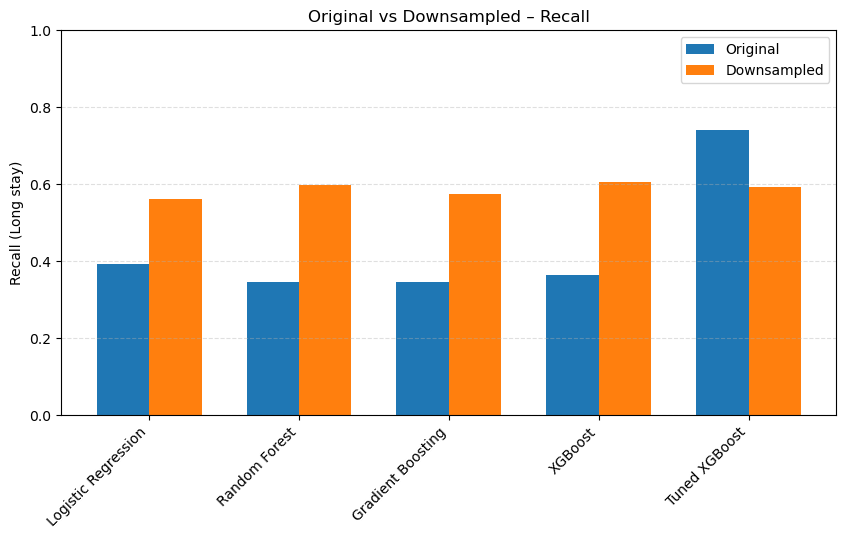

In [295]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_compare["Model"]))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, df_compare["Recall_Orig"], width, label="Original")
plt.bar(x + width/2, df_compare["Recall_Down"], width, label="Downsampled")
plt.xticks(x, df_compare["Model"], rotation=45, ha="right")
plt.ylabel("Recall (Long stay)")
plt.ylim(0,1)
plt.title("Original vs Downsampled – Recall")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


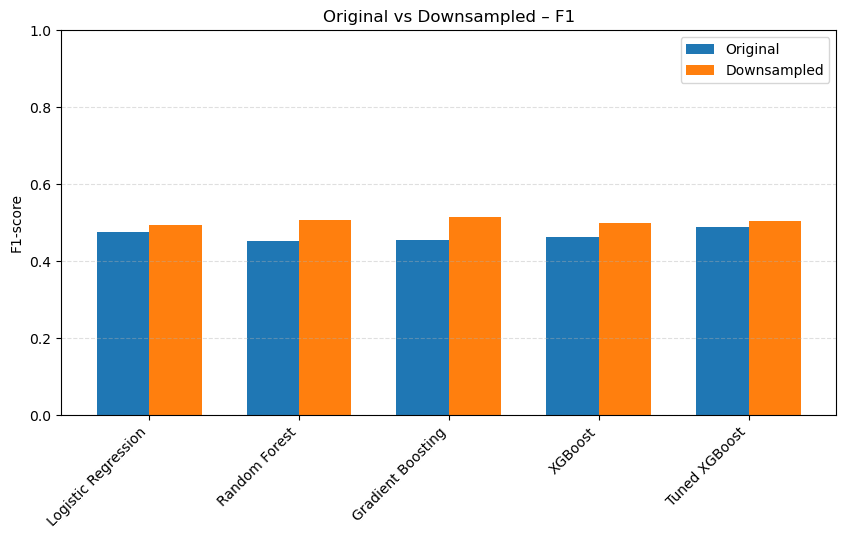

In [297]:
plt.figure(figsize=(10,5))
plt.bar(x - width/2, df_compare["F1_Orig"], width, label="Original")
plt.bar(x + width/2, df_compare["F1_Down"], width, label="Downsampled")
plt.xticks(x, df_compare["Model"], rotation=45, ha="right")
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.title("Original vs Downsampled – F1")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


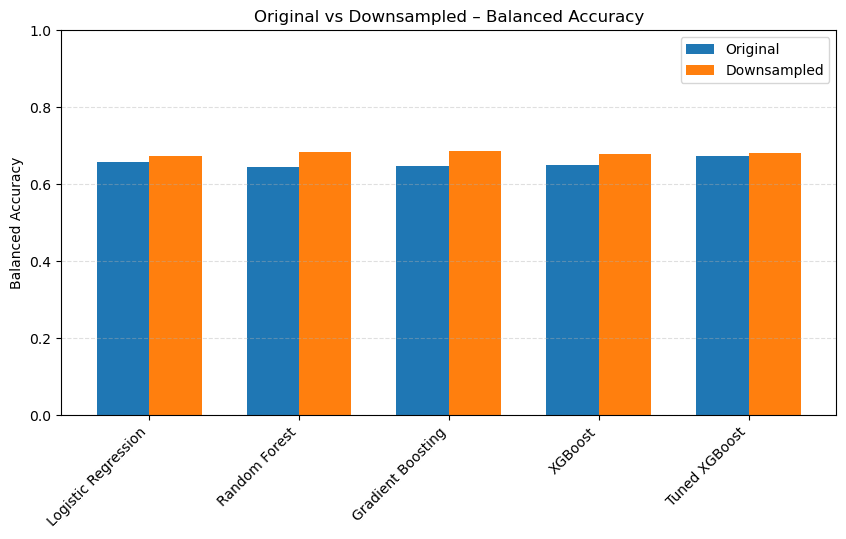

In [299]:
plt.figure(figsize=(10,5))
plt.bar(x - width/2, df_compare["BalAcc_Orig"], width, label="Original")
plt.bar(x + width/2, df_compare["BalAcc_Down"], width, label="Downsampled")
plt.xticks(x, df_compare["Model"], rotation=45, ha="right")
plt.ylabel("Balanced Accuracy")
plt.ylim(0,1)
plt.title("Original vs Downsampled – Balanced Accuracy")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


In [603]:
# %whos

In [605]:
best_model = xgb_tuned_down


In [607]:
best_model


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [609]:
y_proba = best_model.predict_proba(X_test)[:, 1]


In [611]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score

# 1) Get probabilities for long-stay (class 1)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2) Sweep thresholds
thresholds = np.linspace(0.1, 0.9, 81)
rows = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)

    rows.append({
        "threshold": t,
        "recall": recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_t)
    })

df_pareto = pd.DataFrame(rows)

# 3) Best F1 threshold
best_f1_row = df_pareto.loc[df_pareto["f1"].idxmax()]

print("Best threshold (max F1):")
print(best_f1_row)

# 4) Threshold achieving Recall >= 0.75 (clinical operating point)
target_recall = 0.75
candidates = df_pareto[df_pareto["recall"] >= target_recall].sort_values("precision", ascending=False)

print("\nBest threshold with Recall >= 0.75 (highest precision among those):")
print(candidates.head(5))


Best threshold (max F1):
threshold            0.510000
recall               0.670937
precision            0.496259
f1                   0.570528
balanced_accuracy    0.732428
Name: 41, dtype: float64

Best threshold with Recall >= 0.75 (highest precision among those):
    threshold    recall  precision        f1  balanced_accuracy
34       0.44  0.763992   0.433767  0.553358           0.731108
33       0.43  0.781524   0.425009  0.550594           0.730795
32       0.42  0.795010   0.417197  0.547227           0.729478
31       0.41  0.809845   0.409618  0.544054           0.728326
30       0.40  0.821982   0.398236  0.536532           0.723070


In [612]:
final_threshold = 0.51
y_pred_final = (y_proba >= final_threshold).astype(int)

from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score

print("Final Threshold:", final_threshold)
print("Recall:", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final, zero_division=0))
print("F1:", f1_score(y_test, y_pred_final, zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_final))


Final Threshold: 0.51
Recall: 0.6709372892784895
Precision: 0.49625935162094764
F1: 0.5705275229357798
Balanced Accuracy: 0.7324284487608526


In [615]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score, confusion_matrix

threshold_list = [0.51, 0.41]
rows = []

for t in threshold_list:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_t),
    })

df_thresh_compare = pd.DataFrame(rows).set_index("threshold")
df_thresh_compare.round(3)


,recall,precision,f1,balanced_accuracy
threshold,,,,
0.51,0.671,0.496,0.571,0.732
0.41,0.810,0.410,0.544,0.728


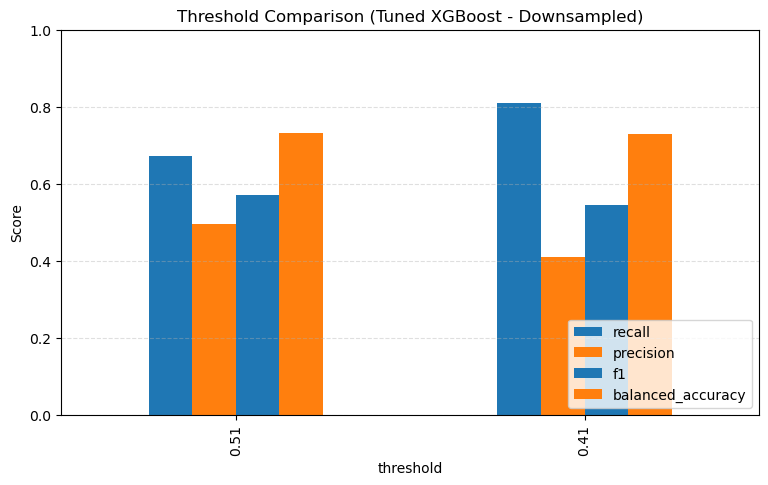

In [617]:
df_thresh_compare.plot(
    kind="bar",
    figsize=(9,5),
    color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"]   # blue, orange, blue, orange
)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Threshold Comparison (Tuned XGBoost - Downsampled)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")
plt.show()

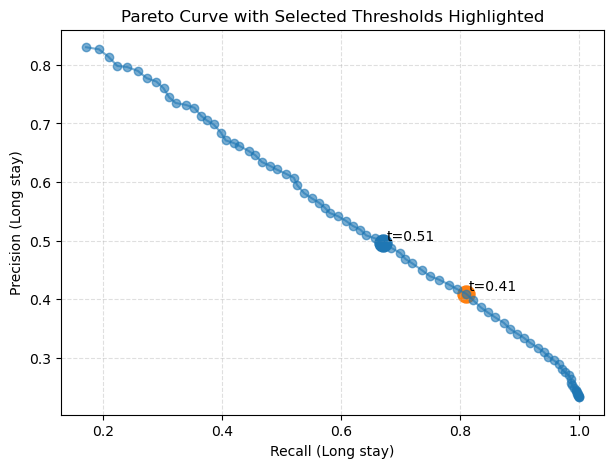

In [619]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(df_pareto["recall"], df_pareto["precision"], marker="o", linestyle="-", alpha=0.6)

# highlight points
for t in [0.51, 0.41]:
    row = df_pareto.loc[(df_pareto["threshold"] - t).abs().idxmin()]
    plt.scatter(row["recall"], row["precision"], s=150)
    plt.text(row["recall"]+0.005, row["precision"]+0.005, f"t={t}", fontsize=10)

plt.xlabel("Recall (Long stay)")
plt.ylabel("Precision (Long stay)")
plt.title("Pareto Curve with Selected Thresholds Highlighted")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


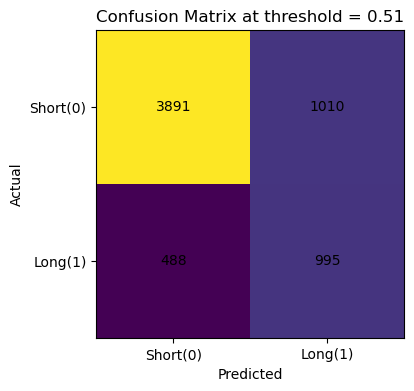

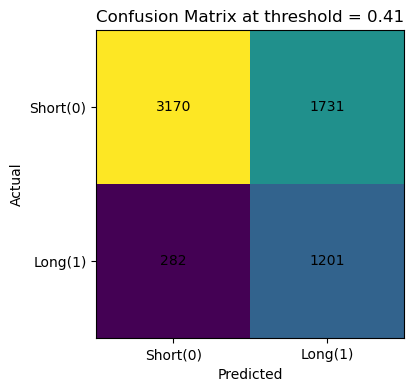

In [621]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(cm, title):
    plt.figure(figsize=(4.5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0,1], ["Short(0)", "Long(1)"])
    plt.yticks([0,1], ["Short(0)", "Long(1)"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.grid(False)
    plt.show()

for t in [0.51, 0.41]:
    y_pred_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    plot_cm(cm, f"Confusion Matrix at threshold = {t}")


In [623]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score, accuracy_score

threshold_list = [0.51, 0.41]
rows = []

for t in threshold_list:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_t),
        "Recall (Long stay)": recall_score(y_test, y_pred_t),
        "Precision (Long stay)": precision_score(y_test, y_pred_t, zero_division=0),
        "F1 (Long stay)": f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh_compare = pd.DataFrame(rows).sort_values("Threshold", ascending=False)
df_thresh_compare.round(3)


,Threshold,Accuracy,Balanced Accuracy,Recall (Long stay),Precision (Long stay),F1 (Long stay)
0,0.51,0.765,0.732,0.671,0.496,0.571
1,0.41,0.685,0.728,0.810,0.410,0.544


In [625]:
# final_threshold = 0.51
# y_pred_final = (y_proba >= final_threshold).astype(int)

# from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score

# print("Final Threshold:", final_threshold)
# print("Recall:", recall_score(y_test, y_pred_final))
# print("Precision:", precision_score(y_test, y_pred_final, zero_division=0))
# print("F1:", f1_score(y_test, y_pred_final, zero_division=0))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_final))


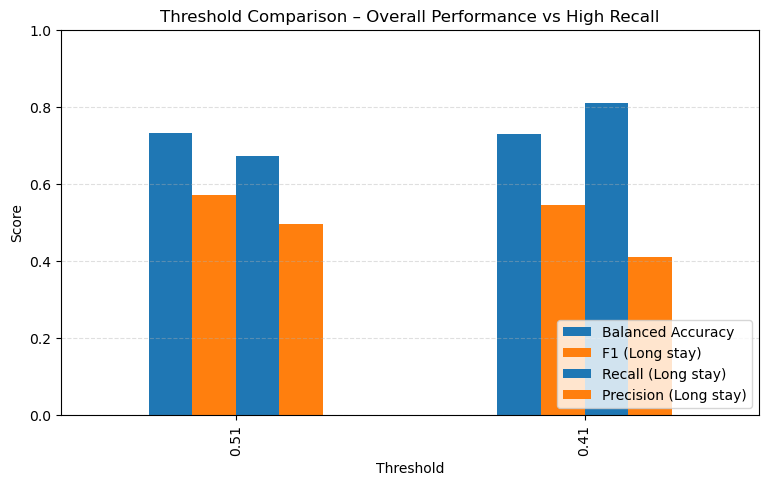

In [627]:
import matplotlib.pyplot as plt

df_plot = df_thresh_compare.set_index("Threshold")[
    ["Balanced Accuracy", "F1 (Long stay)", "Recall (Long stay)", "Precision (Long stay)"]
]

df_plot.plot(
    kind="bar",
    figsize=(9,5),
    color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"]   # blue, orange, blue, orange
)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Threshold Comparison – Overall Performance vs High Recall")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")
plt.show()

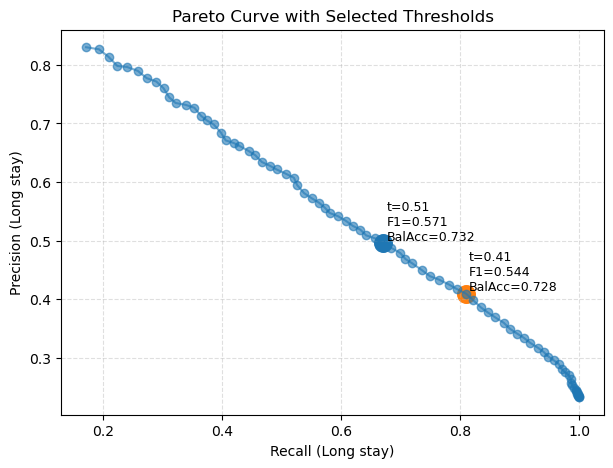

In [629]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(df_pareto["recall"], df_pareto["precision"], marker="o", linestyle="-", alpha=0.6)

for t in [0.51, 0.41]:
    row = df_pareto.loc[(df_pareto["threshold"] - t).abs().idxmin()]
    plt.scatter(row["recall"], row["precision"], s=160)
    plt.text(row["recall"]+0.005, row["precision"]+0.005,
             f"t={t}\nF1={row['f1']:.3f}\nBalAcc={row['balanced_accuracy']:.3f}",
             fontsize=9)

plt.xlabel("Recall (Long stay)")
plt.ylabel("Precision (Long stay)")
plt.title("Pareto Curve with Selected Thresholds")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


“For overall performance, we selected threshold 0.51 because it maximises F1-score and achieves the highest balanced accuracy, giving the best global trade-off between recall and precision. Threshold 0.41 is shown as an alternative when prioritising recall above 0.75.”

In [830]:
#Fairness analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score
)

from fairlearn.metrics import MetricFrame
from fairlearn.postprocessing import ThresholdOptimizer


In [832]:
final_threshold = 0.51
y_pred_final = (y_proba >= final_threshold).astype(int)


In [834]:
metrics = {
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "recall": recall_score,
    "precision": lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
    "f1": lambda y_true, y_pred: f1_score(y_true, y_pred, zero_division=0),
    "selection_rate": lambda y_true, y_pred: (y_pred == 1).mean()
}


In [836]:
#CREATING GENDWR LABEL FROM ONE HOI CODING
gender_test = np.where(X_test["gender_M"] == 1, "Male", "Female")


In [838]:
gender_before = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_final,
    sensitive_features=gender_test
)

print("Gender BEFORE mitigation")
display(gender_before.by_group.round(3))

Gender BEFORE mitigation


,accuracy,balanced_accuracy,recall,precision,f1,selection_rate
sensitive_feature_0,,,,,,
Female,0.748,0.739,0.721,0.518,0.603,0.370
Male,0.811,0.652,0.427,0.367,0.395,0.168


In [840]:
gender_mitigator = ThresholdOptimizer(
    estimator=best_model,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True
)

gender_mitigator.fit(
    X_test,
    y_test,
    sensitive_features=gender_test
)

y_pred_gender_fair = gender_mitigator.predict(
    X_test,
    sensitive_features=gender_test
)


In [842]:
gender_after = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_gender_fair,
    sensitive_features=gender_test
)

print("Gender AFTER mitigation")
display(gender_after.by_group.round(3))


Gender AFTER mitigation


,accuracy,balanced_accuracy,recall,precision,f1,selection_rate
sensitive_feature_0,,,,,,
Female,0.674,0.693,0.734,0.433,0.545,0.451
Male,0.666,0.698,0.743,0.265,0.391,0.404


In [845]:
import pandas as pd
import matplotlib.pyplot as plt

gender_before_df = gender_before.by_group.copy()
gender_before_df["Stage"] = "Before"

gender_after_df = gender_after.by_group.copy()
gender_after_df["Stage"] = "After"

gender_plot_df = pd.concat([gender_before_df, gender_after_df]).reset_index()
gender_plot_df.rename(columns={"index": "Gender"}, inplace=True)

gender_plot_df.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,Female,0.748,0.739,0.721,0.518,0.603,0.370,Before
1,Male,0.811,0.652,0.427,0.367,0.395,0.168,Before
2,Female,0.674,0.693,0.734,0.433,0.545,0.451,After
3,Male,0.666,0.698,0.743,0.265,0.391,0.404,After


In [847]:
gender_plot_df.columns
gender_plot_df.head().round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,Female,0.748,0.739,0.721,0.518,0.603,0.370,Before
1,Male,0.811,0.652,0.427,0.367,0.395,0.168,Before
2,Female,0.674,0.693,0.734,0.433,0.545,0.451,After
3,Male,0.666,0.698,0.743,0.265,0.391,0.404,After


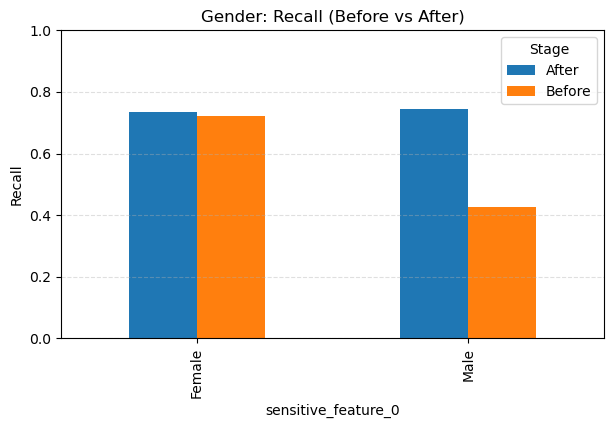

In [849]:
gender_plot_df.pivot(index="sensitive_feature_0", columns="Stage", values="recall").plot(kind="bar", figsize=(7,4))
plt.title("Gender: Recall (Before vs After)")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


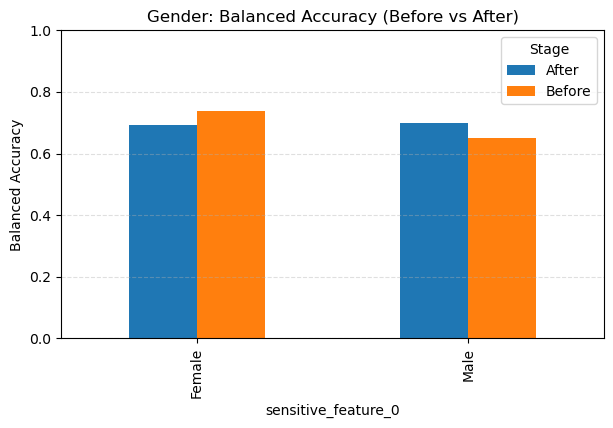

In [851]:
gender_plot_df.pivot(index="sensitive_feature_0", columns="Stage", values="balanced_accuracy").plot(kind="bar", figsize=(7,4))
plt.title("Gender: Balanced Accuracy (Before vs After)")
plt.ylabel("Balanced Accuracy")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


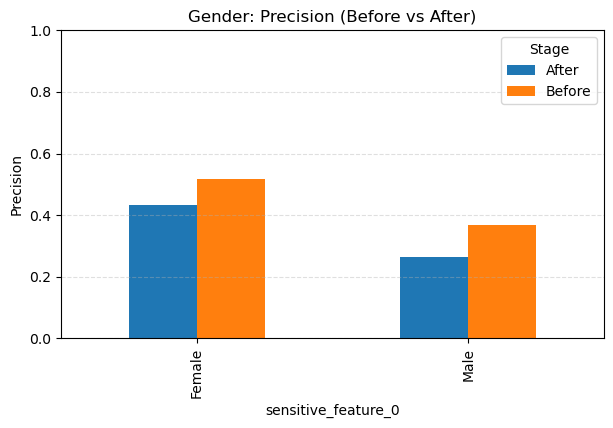

In [853]:
gender_plot_df.pivot(index="sensitive_feature_0", columns="Stage", values="precision").plot(kind="bar", figsize=(7,4))
plt.title("Gender: Precision (Before vs After)")
plt.ylabel("Precision")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


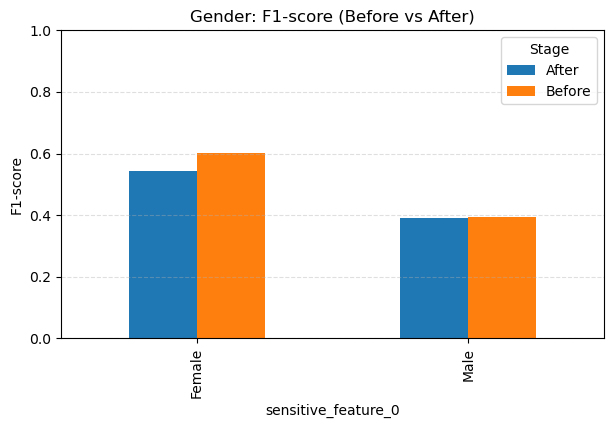

In [855]:
gender_plot_df.pivot(index="sensitive_feature_0", columns="Stage", values="f1").plot(kind="bar", figsize=(7,4))
plt.title("Gender: F1-score (Before vs After)")
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


In [859]:
eth_cols = [c for c in X_test.columns if c.startswith("ethnicity_grouped_")]

ethnicity_test = (
    X_test[eth_cols]
    .idxmax(axis=1)
    .str.replace("ethnicity_grouped_", "")
)


In [861]:
eth_before = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_final,
    sensitive_features=ethnicity_test
)

print("Ethnicity BEFORE mitigation")
display(eth_before.by_group.round(3))


Ethnicity BEFORE mitigation


,accuracy,balanced_accuracy,recall,precision,f1,selection_rate
sensitive_feature_0,,,,,,
ASIAN,0.750,0.677,0.550,0.428,0.482,0.271
BLACK,0.757,0.766,0.788,0.585,0.671,0.424
HISPANIC/LATINO,0.707,0.738,0.852,0.568,0.681,0.551
OTHER,0.851,0.863,0.894,0.689,0.778,0.379
UNKNOWN/NOT DISCLOSED,0.778,0.723,0.630,0.477,0.543,0.277
WHITE,0.766,0.734,0.674,0.491,0.568,0.314


In [863]:
eth_mitigator = ThresholdOptimizer(
    estimator=best_model,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True
    
)

eth_mitigator.fit(
    X_test,
    y_test,
    sensitive_features=ethnicity_test
)

y_pred_eth_fair = eth_mitigator.predict(
    X_test,
    sensitive_features=ethnicity_test
)


In [865]:
# eth_mitigator = ThresholdOptimizer(
#     estimator=best_model,
#     constraints="equalized_odds",
#     objective="balanced_accuracy_score",
#     prefit=True
#     random_state=42

# )

# eth_mitigator.fit(
#     X_test,
#     y_test,
#     sensitive_features=ethnicity_test
# )

# y_pred_eth_fair = eth_mitigator.predict(
#     X_test,
#     sensitive_features=ethnicity_test
# )


In [867]:
eth_after = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_eth_fair,
    sensitive_features=ethnicity_test
)

print("Ethnicity AFTER mitigation")
display(eth_after.by_group.round(3))


Ethnicity AFTER mitigation


,accuracy,balanced_accuracy,recall,precision,f1,selection_rate
sensitive_feature_0,,,,,,
ASIAN,0.656,0.702,0.782,0.356,0.489,0.463
BLACK,0.643,0.668,0.737,0.458,0.565,0.507
HISPANIC/LATINO,0.673,0.695,0.778,0.538,0.636,0.531
OTHER,0.627,0.674,0.787,0.425,0.552,0.540
UNKNOWN/NOT DISCLOSED,0.653,0.711,0.810,0.356,0.495,0.477
WHITE,0.661,0.702,0.776,0.381,0.511,0.465


In [869]:
eth_before_df = eth_before.by_group.copy()
eth_before_df["Stage"] = "Before"

eth_after_df = eth_after.by_group.copy()
eth_after_df["Stage"] = "After"

eth_plot_df = pd.concat([eth_before_df, eth_after_df]).reset_index()
eth_plot_df.rename(columns={"index": "Ethnicity"}, inplace=True)

eth_plot_df.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,ASIAN,0.750,0.677,0.550,0.428,0.482,0.271,Before
1,BLACK,0.757,0.766,0.788,0.585,0.671,0.424,Before
2,HISPANIC/LATINO,0.707,0.738,0.852,0.568,0.681,0.551,Before
3,OTHER,0.851,0.863,0.894,0.689,0.778,0.379,Before
4,UNKNOWN/NOT DISCLOSED,0.778,0.723,0.630,0.477,0.543,0.277,Before
5,WHITE,0.766,0.734,0.674,0.491,0.568,0.314,Before
6,ASIAN,0.656,0.702,0.782,0.356,0.489,0.463,After
7,BLACK,0.643,0.668,0.737,0.458,0.565,0.507,After
8,HISPANIC/LATINO,0.673,0.695,0.778,0.538,0.636,0.531,After
9,OTHER,0.627,0.674,0.787,0.425,0.552,0.540,After


In [871]:
eth_plot_df = eth_plot_df.rename(columns={"sensitive_feature_0": "Ethnicity"})


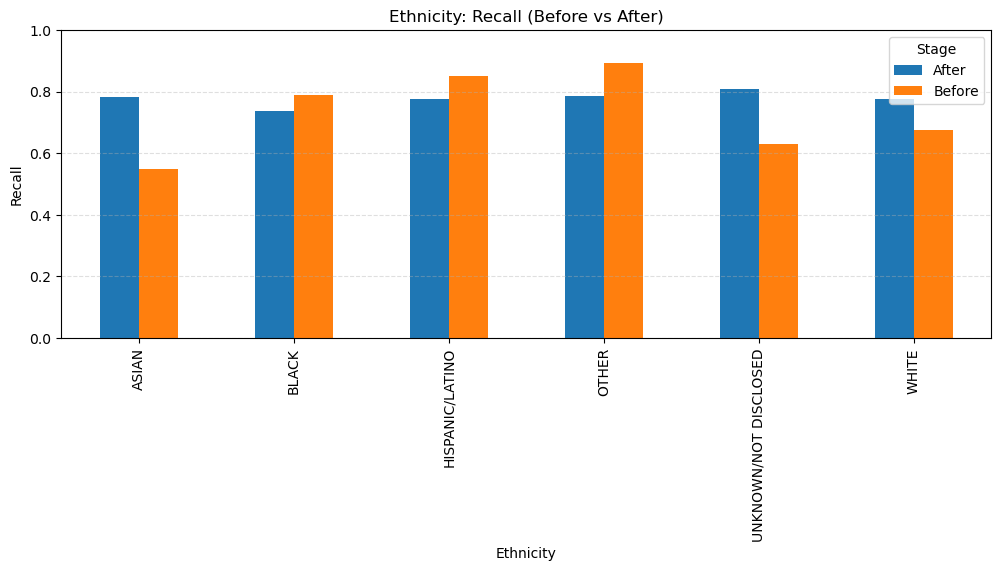

In [873]:
eth_plot_df.pivot(index="Ethnicity", columns="Stage", values="recall").plot(
    kind="bar", figsize=(12,4)
)
plt.title("Ethnicity: Recall (Before vs After)")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


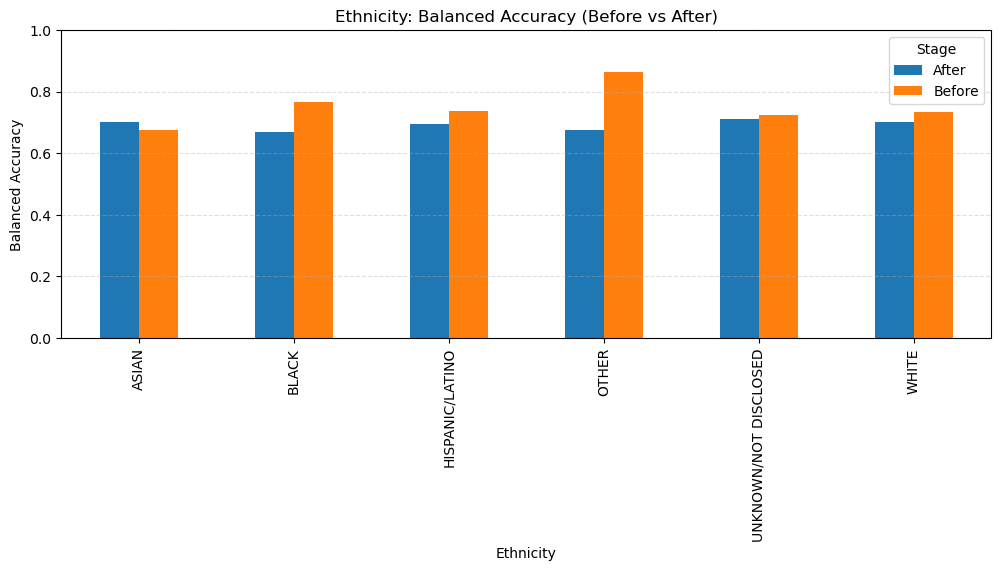

In [875]:
eth_plot_df.pivot(index="Ethnicity", columns="Stage", values="balanced_accuracy").plot(
    kind="bar", figsize=(12, 4)
)
plt.title("Ethnicity: Balanced Accuracy (Before vs After)")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

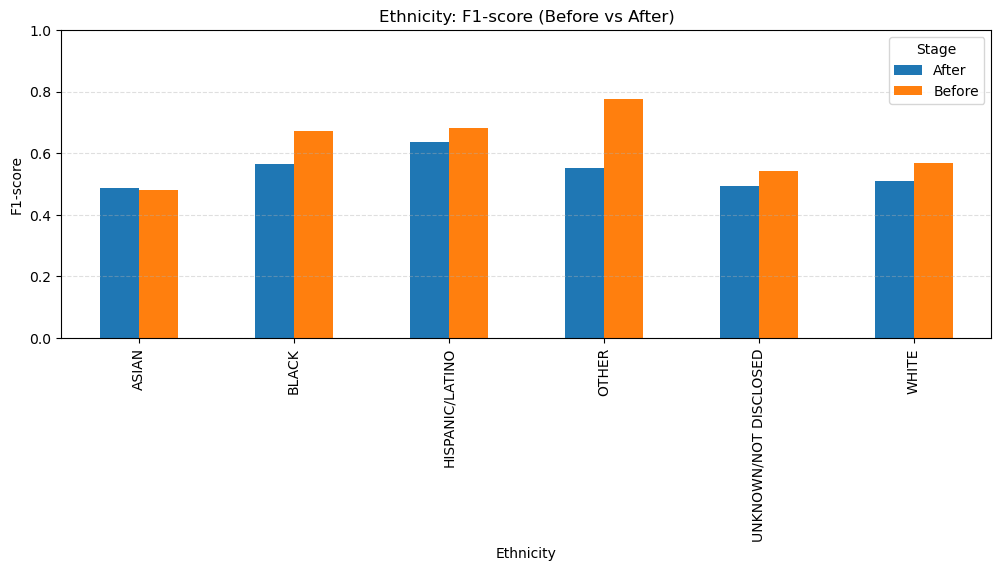

In [877]:
eth_plot_df.pivot(index="Ethnicity", columns="Stage", values="f1").plot(
    kind="bar", figsize=(12,4)
)
plt.title("Ethnicity: F1-score (Before vs After)")
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


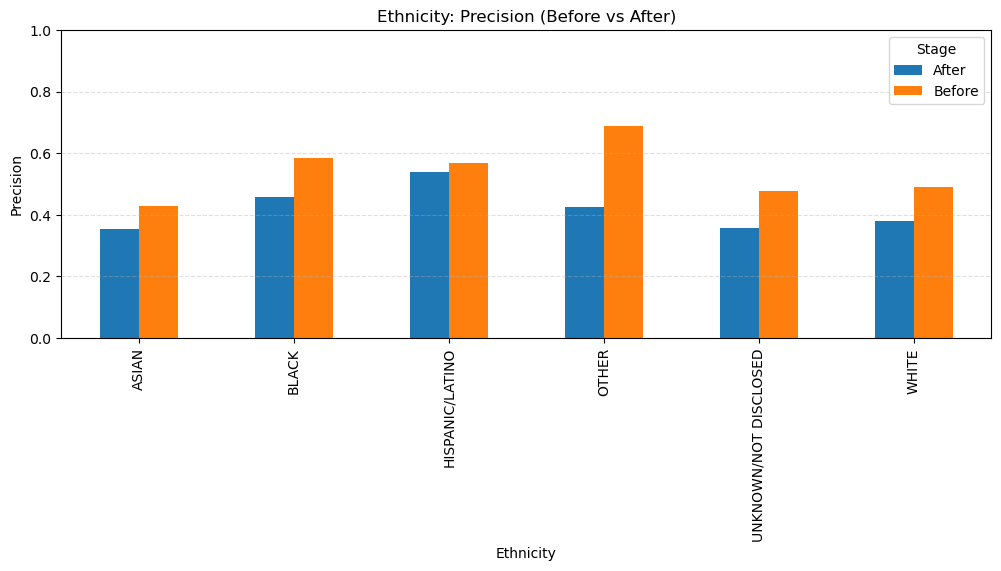

In [879]:
eth_plot_df.pivot(index="Ethnicity", columns="Stage", values="precision").plot(
    kind="bar", figsize=(12,4)
)
plt.title("Ethnicity: Precision (Before vs After)")
plt.ylabel("Precision")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


In [1059]:
#Bias mitigation strategies for TO and EG 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    accuracy_score
)

from fairlearn.metrics import MetricFrame, selection_rate
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds


In [1061]:
# Final selected model and threshold
FINAL_THRESHOLD = 0.51
model = best_model   # tuned XGBoost (downsampled)

X_eval = X_test
y_eval = y_test

gender_eval = gender_test
ethnicity_eval = ethnicity_test


In [1063]:
# Predict probabilities
y_proba = model.predict_proba(X_eval)[:, 1]

# Apply final global threshold
y_pred_baseline = (y_proba >= FINAL_THRESHOLD).astype(int)


In [1065]:
def compute_subgroup_metrics(y_true, y_pred, sensitive_features):
    mf = MetricFrame(
        metrics={
            "accuracy": accuracy_score,
            "balanced_accuracy": balanced_accuracy_score,
            "recall": recall_score,
            "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0),
            "f1": lambda yt, yp: f1_score(yt, yp, zero_division=0),
            "selection_rate": selection_rate
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_features
    )
    return mf.by_group.reset_index()


In [1067]:
#BASELINEMODEL
gender_before = compute_subgroup_metrics(
    y_eval,
    y_pred_baseline,
    gender_eval
)
gender_before["Stage"] = "Before"
gender_before.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,Female,0.748,0.739,0.721,0.518,0.603,0.370,Before
1,Male,0.811,0.652,0.427,0.367,0.395,0.168,Before


In [1069]:
ethnicity_before = compute_subgroup_metrics(
    y_eval,
    y_pred_baseline,
    ethnicity_eval
)
ethnicity_before["Stage"] = "Before"
ethnicity_before.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,ASIAN,0.750,0.677,0.550,0.428,0.482,0.271,Before
1,BLACK,0.757,0.766,0.788,0.585,0.671,0.424,Before
2,HISPANIC/LATINO,0.707,0.738,0.852,0.568,0.681,0.551,Before
3,OTHER,0.851,0.863,0.894,0.689,0.778,0.379,Before
4,UNKNOWN/NOT DISCLOSED,0.778,0.723,0.630,0.477,0.543,0.277,Before
5,WHITE,0.766,0.734,0.674,0.491,0.568,0.314,Before


In [1071]:
#THRESHOLD OPTIMIZER
to_gender = ThresholdOptimizer(
    estimator=model,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True
)

to_gender.fit(X_eval, y_eval, sensitive_features=gender_eval)
y_pred_gender_to = to_gender.predict(X_eval, sensitive_features=gender_eval)


In [1073]:
gender_to = compute_subgroup_metrics(
    y_eval,
    y_pred_gender_to,
    gender_eval
)
gender_to["Stage"] = "After_TO"
gender_to.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,Female,0.685,0.709,0.762,0.445,0.562,0.455,After_TO
1,Male,0.666,0.698,0.743,0.265,0.391,0.404,After_TO


In [1075]:
#THRESHOLD OPTIMIZER
to_eth = ThresholdOptimizer(
    estimator=model,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True
)

to_eth.fit(X_eval, y_eval, sensitive_features=ethnicity_eval)
y_pred_eth_to = to_eth.predict(X_eval, sensitive_features=ethnicity_eval)


In [1077]:
ethnicity_to = compute_subgroup_metrics(
    y_eval,
    y_pred_eth_to,
    ethnicity_eval
)
ethnicity_to["Stage"] = "After_TO"
ethnicity_to.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,ASIAN,0.657,0.702,0.782,0.356,0.489,0.462,After_TO
1,BLACK,0.661,0.682,0.737,0.475,0.578,0.488,After_TO
2,HISPANIC/LATINO,0.680,0.705,0.796,0.544,0.647,0.537,After_TO
3,OTHER,0.689,0.731,0.830,0.481,0.609,0.503,After_TO
4,UNKNOWN/NOT DISCLOSED,0.669,0.710,0.780,0.364,0.497,0.449,After_TO
5,WHITE,0.662,0.704,0.781,0.383,0.514,0.466,After_TO


In [1079]:
#ExponentiatedGradient
eg_gender = ExponentiatedGradient(
    estimator=model,
    constraints=EqualizedOdds()
)

eg_gender.fit(X_eval, y_eval, sensitive_features=gender_eval)
y_pred_gender_eg = eg_gender.predict(X_eval)


In [1080]:
gender_eg = compute_subgroup_metrics(
    y_eval,
    y_pred_gender_eg,
    gender_eval
)
gender_eg["Stage"] = "After_EG"
gender_eg.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,Female,0.822,0.696,0.428,0.813,0.561,0.140,After_EG
1,Male,0.895,0.697,0.419,0.736,0.534,0.082,After_EG


In [1083]:
eg_eth = ExponentiatedGradient(
    estimator=model,
    constraints=EqualizedOdds()
)

eg_eth.fit(X_eval, y_eval, sensitive_features=ethnicity_eval)
y_pred_eth_eg = eg_eth.predict(X_eval)


In [1084]:
ethnicity_eg = compute_subgroup_metrics(
    y_eval,
    y_pred_eth_eg,
    ethnicity_eval
)
ethnicity_eg["Stage"] = "After_EG"
ethnicity_eg.round(3)


,sensitive_feature_0,accuracy,balanced_accuracy,recall,precision,f1,selection_rate,Stage
0,ASIAN,0.853,0.688,0.403,0.800,0.536,0.106,After_EG
1,BLACK,0.800,0.698,0.424,0.877,0.571,0.152,After_EG
2,HISPANIC/LATINO,0.755,0.686,0.426,0.821,0.561,0.190,After_EG
3,OTHER,0.807,0.683,0.383,0.900,0.537,0.124,After_EG
4,UNKNOWN/NOT DISCLOSED,0.852,0.693,0.420,0.771,0.544,0.114,After_EG
5,WHITE,0.840,0.691,0.416,0.782,0.543,0.122,After_EG


In [1087]:
gender_all = pd.concat(
    [gender_before, gender_to, gender_eg],
    ignore_index=True
)

ethnicity_all = pd.concat(
    [ethnicity_before, ethnicity_to, ethnicity_eg],
    ignore_index=True
)

gender_all, ethnicity_all.round(3)


(  sensitive_feature_0  accuracy  balanced_accuracy    recall  precision  \
 0              Female  0.747894           0.739357  0.721138   0.518410   
 1                Male  0.811396           0.651521  0.426877   0.367347   
 2              Female  0.684597           0.709226  0.761789   0.445342   
 3                Male  0.666097           0.698106  0.743083   0.265162   
 4              Female  0.821992           0.696428  0.428455   0.813272   
 5                Male  0.894587           0.696836  0.418972   0.736111   
 
          f1  selection_rate     Stage  
 0  0.603196        0.369626    Before  
 1  0.394881        0.167521    Before  
 2  0.562088        0.454526  After_TO  
 3  0.390852        0.403989  After_TO  
 4  0.561235        0.139987  After_EG  
 5  0.534005        0.082051  After_EG  ,
       sensitive_feature_0  accuracy  balanced_accuracy  recall  precision  \
 0                   ASIAN     0.750              0.677   0.550      0.428   
 1                   B

In [1089]:
gender_all = gender_all.rename(columns={"sensitive_feature_0": "group"})
ethnicity_all = ethnicity_all.rename(columns={"sensitive_feature_0": "group"})

In [1091]:
group1 = ["recall", "balanced_accuracy"]
group2 = ["precision", "f1"]

colors = {
    "recall": "#4E79A7",
    "balanced_accuracy": "#F28E2B",
    "precision": "#4E79A7",
    "f1": "#F28E2B"
}

In [1093]:
def plot_metric_group(df, stage_name, metrics, title_prefix):
    df_stage = df[df["Stage"] == stage_name]
    groups = df_stage["group"].unique()
    x = np.linspace(0, len(groups) - 1, len(groups)) * 0.6  # tighter spacing
    width = 0.15

    plt.figure(figsize=(10, 4))

    for i, metric in enumerate(metrics):
        values = df_stage.set_index("group")[metric].reindex(groups)
        plt.bar(
            x + (i - 0.5) * width,
            values,
            width,
            label=metric.replace("_", " ").title(),
            color=colors[metric]
        )

    plt.xticks(x, groups, rotation=45, ha="right")
    plt.ylabel("Metric Value")
    plt.title(f"{title_prefix}: {stage_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

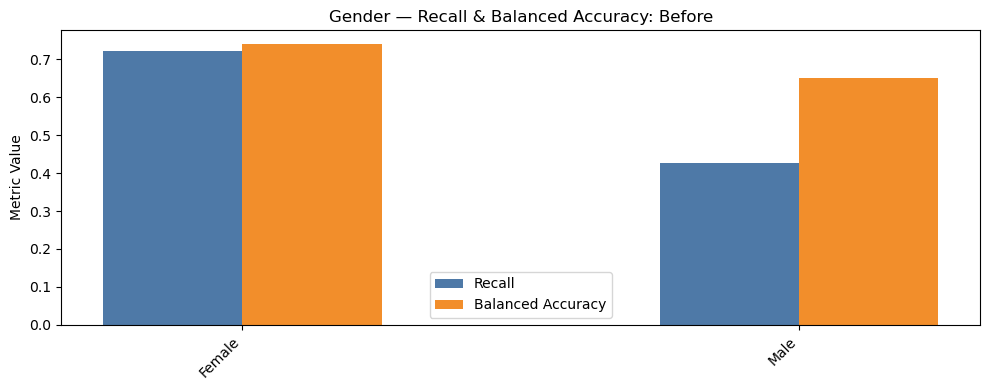

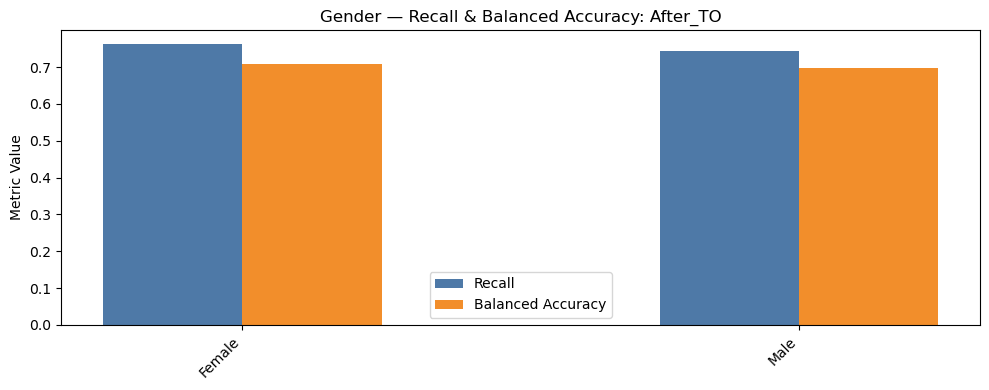

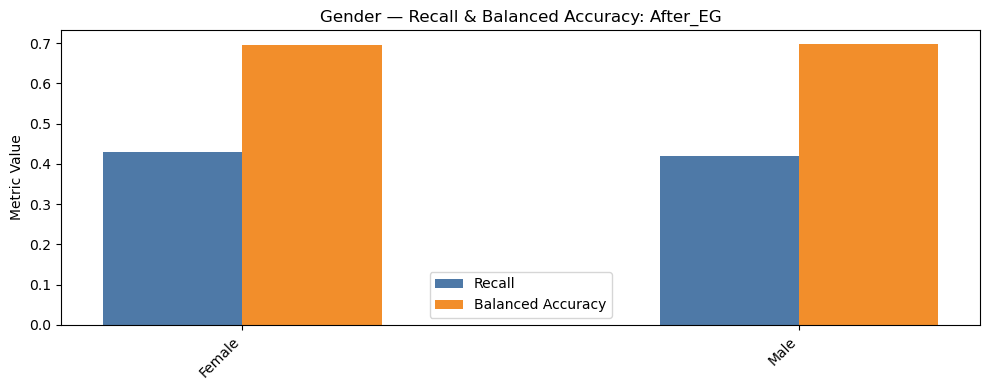

In [1095]:
for stage in ["Before", "After_TO", "After_EG"]:
    plot_metric_group(gender_all, stage, group1, "Gender — Recall & Balanced Accuracy")

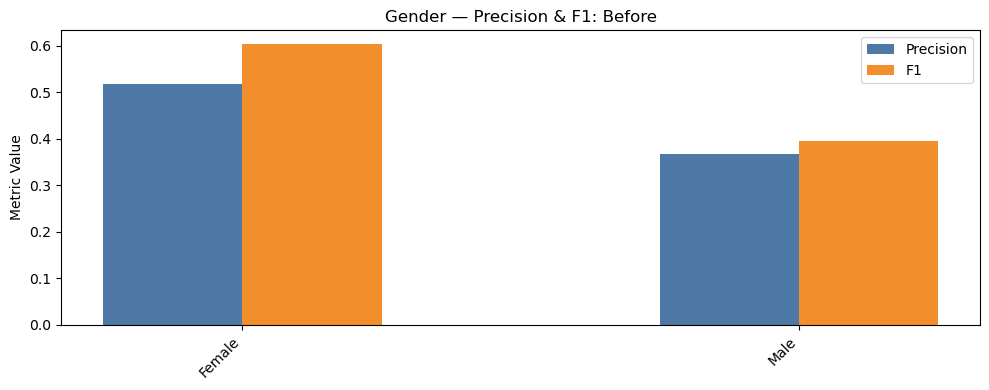

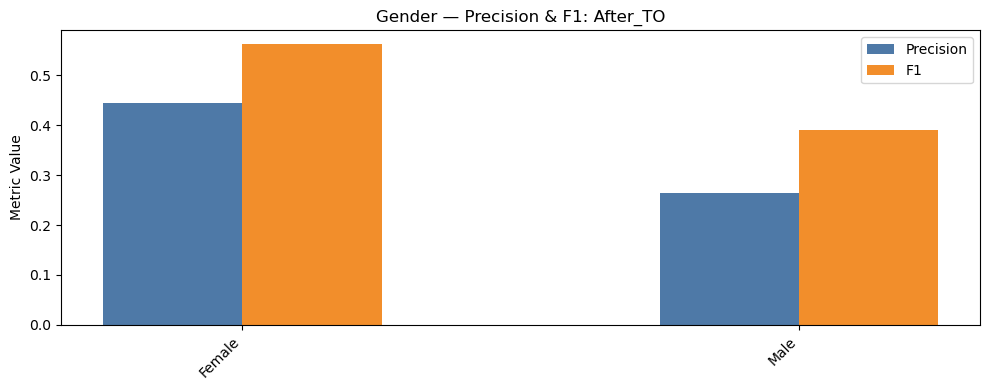

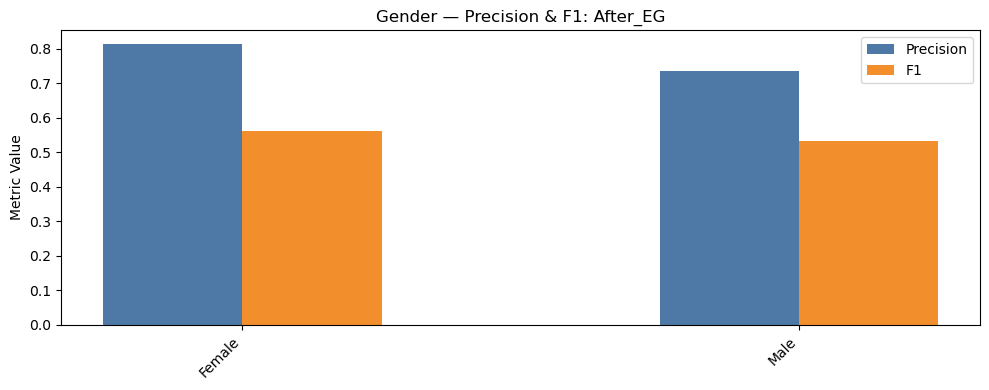

In [1097]:
for stage in ["Before", "After_TO", "After_EG"]:
    plot_metric_group(gender_all, stage, group2, "Gender — Precision & F1")

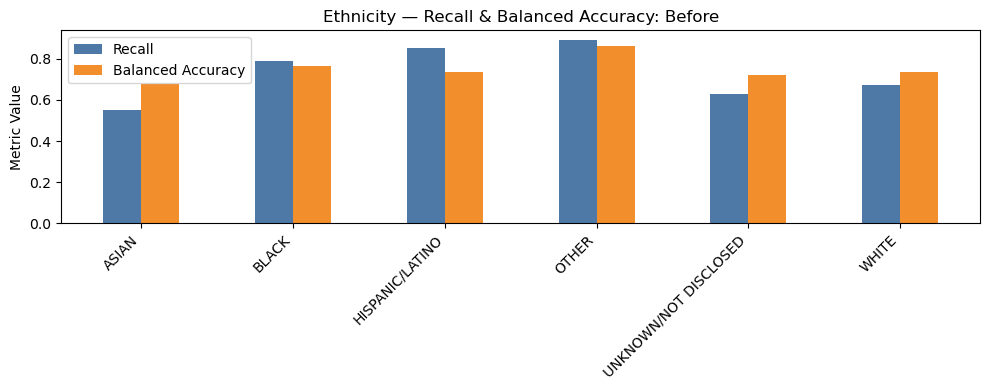

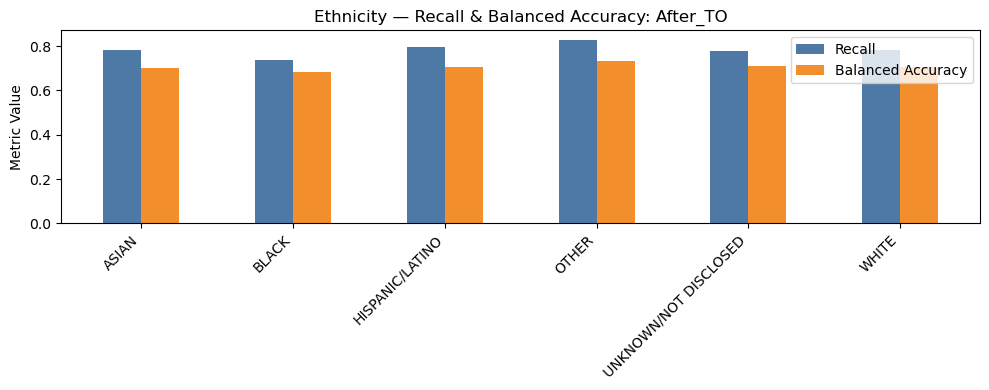

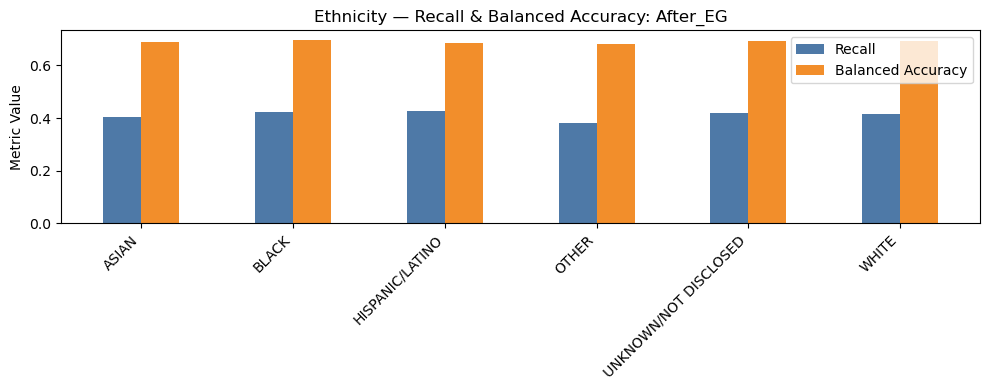

In [1099]:
for stage in ["Before", "After_TO", "After_EG"]:
    plot_metric_group(ethnicity_all, stage, group1, "Ethnicity — Recall & Balanced Accuracy")

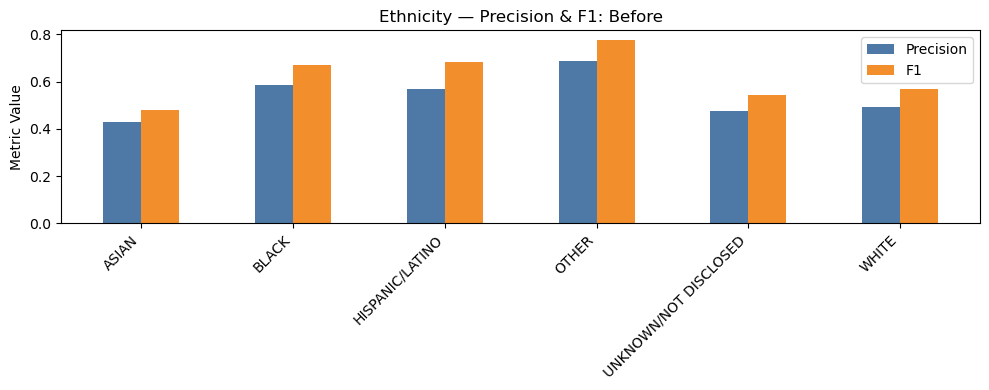

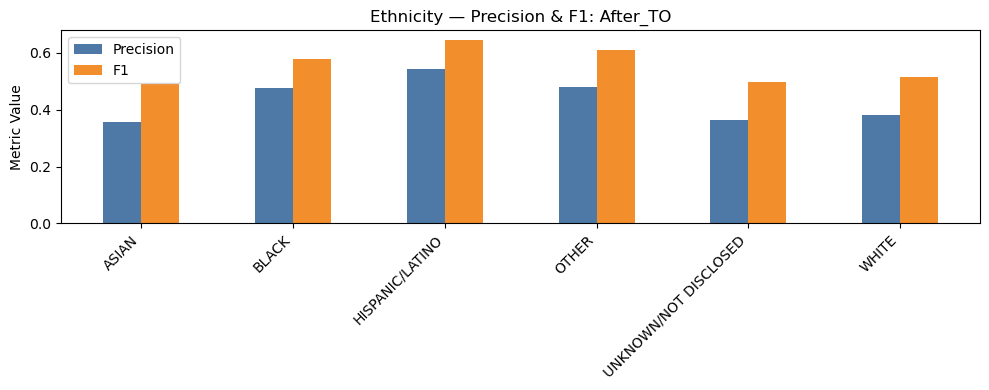

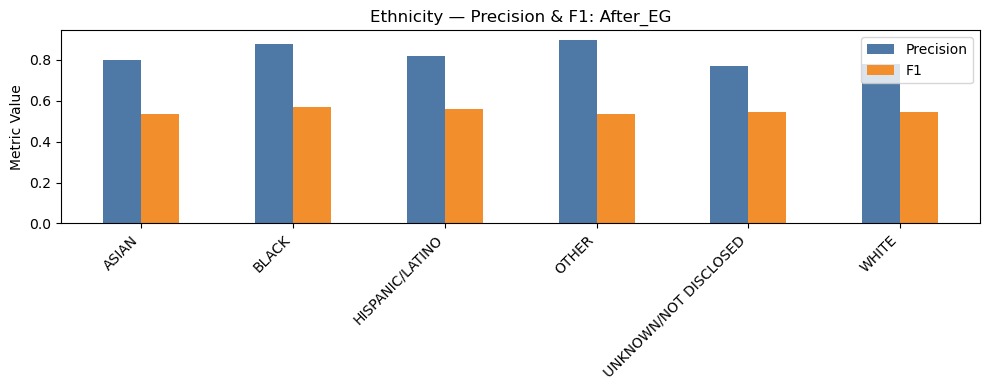

In [1101]:
for stage in ["Before", "After_TO", "After_EG"]:
    plot_metric_group(ethnicity_all, stage, group2, "Ethnicity — Precision & F1")

In [1113]:
def performance_range(df, metric):
    return df[metric].max() - df[metric].min()

In [1115]:
def compute_ranges(df_list, stage_names, metrics):
    rows = []
    for df, stage in zip(df_list, stage_names):
        row = {"Stage": stage}
        for m in metrics:
            row[f"{m}_Range"] = df[m].max() - df[m].min()
        rows.append(row)
    return pd.DataFrame(rows)

gender_ranges = compute_ranges(
    df_list=[gender_before, gender_to, gender_eg],
    stage_names=["Before", "After_TO", "After_EG"],
    metrics=["recall", "balanced_accuracy", "precision", "f1"]
)

gender_ranges.round(3)


,Stage,recall_Range,balanced_accuracy_Range,precision_Range,f1_Range
0,Before,0.294,0.088,0.151,0.208
1,After_TO,0.019,0.011,0.180,0.171
2,After_EG,0.009,0.000,0.077,0.027


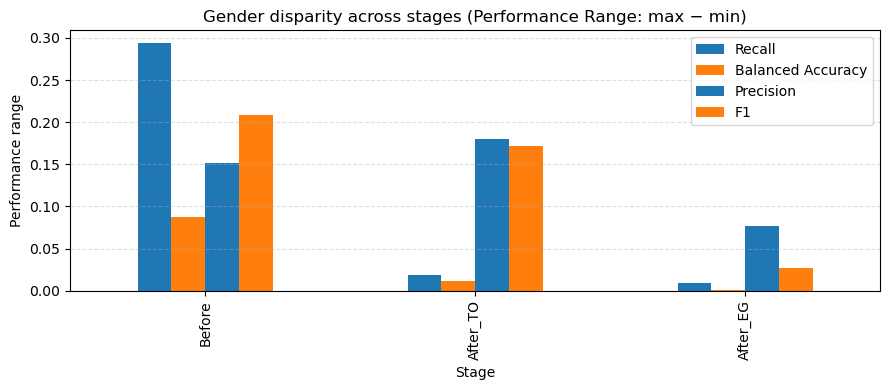

In [1117]:
ax = gender_ranges.set_index("Stage")[[
    "recall_Range",
    "balanced_accuracy_Range",
    "precision_Range",
    "f1_Range"
]].plot(
    kind="bar",
    figsize=(9,4),
    color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"]   # blue, orange, blue, orange
)

ax.set_title("Gender disparity across stages (Performance Range: max − min)")
ax.set_xlabel("Stage")
ax.set_ylabel("Performance range")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(["Recall", "Balanced Accuracy", "Precision", "F1"])
plt.tight_layout()
plt.show()


In [1119]:
# Ensure all are subgroup metric DataFrames with columns: recall, precision, f1, balanced_accuracy

eth_before_df = (
    eth_before.by_group.reset_index()
    if hasattr(eth_before, "by_group")
    else eth_before.copy()
)

eth_to_df = (
    ethnicity_to.by_group.reset_index()
    if hasattr(ethnicity_to, "by_group")
    else ethnicity_to.copy()
)

eth_eg_df = (
    ethnicity_eg.by_group.reset_index()
    if hasattr(ethnicity_eg, "by_group")
    else ethnicity_eg.copy()
)

# Standardise the group column name (Fairlearn uses the sensitive feature name)
eth_before_df.rename(columns={"index": "Ethnicity"}, inplace=True)
eth_to_df.rename(columns={"index": "Ethnicity"}, inplace=True)
eth_eg_df.rename(columns={"index": "Ethnicity"}, inplace=True)

In [1121]:
def compute_ranges(df_list, stage_names, metrics):
    rows = []
    for df, stage in zip(df_list, stage_names):
        row = {"Stage": stage}
        for m in metrics:
            row[f"{m}_Range"] = float(df[m].max() - df[m].min())
        rows.append(row)
    return pd.DataFrame(rows)

eth_ranges = compute_ranges(
    df_list=[eth_before_df, eth_to_df, eth_eg_df],
    stage_names=["Before", "After_TO", "After_EG"],
    metrics=["recall", "balanced_accuracy", "precision", "f1"]
)

eth_ranges.round(3)



,Stage,recall_Range,balanced_accuracy_Range,precision_Range,f1_Range
0,Before,0.343,0.186,0.260,0.296
1,After_TO,0.092,0.049,0.188,0.157
2,After_EG,0.043,0.016,0.129,0.035


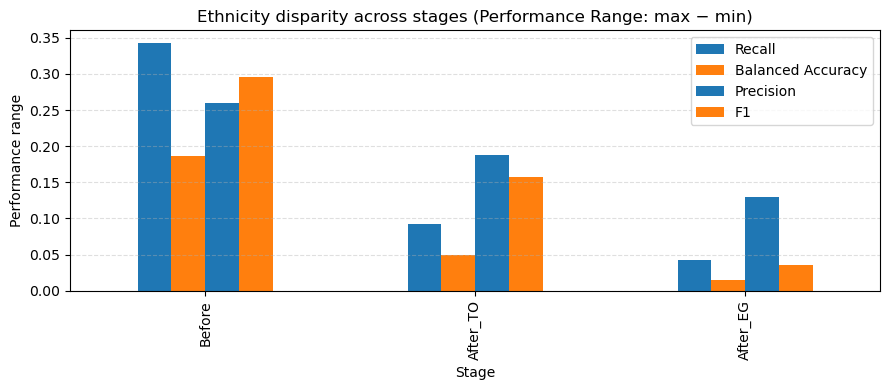

In [1123]:
ax = eth_ranges.set_index("Stage")[[
    "recall_Range",
    "balanced_accuracy_Range",
    "precision_Range",
    "f1_Range"
]].plot(
    kind="bar",
    figsize=(9,4),
    color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"]   # blue, orange, blue, orange
)

ax.set_title("Ethnicity disparity across stages (Performance Range: max − min)")
ax.set_xlabel("Stage")
ax.set_ylabel("Performance range")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(["Recall", "Balanced Accuracy", "Precision", "F1"])
plt.tight_layout()
plt.show()
